# 🎬 Movie Recommender System
## Personalized Movie Recommendation System


| | |
|--|--|
| **Author** | Harish S V |
| **Date** | March 2026 |
| **Dataset** | MovieLens 1M |
| **Tools** | Python, Google Colab |

---
### 🎯 Project Goal:
Build a personalized movie recommender
system using
collaborative filtering techniques to
enhance user experience through
accurate and relevant recommendations.

## Movie Recommender Systems

**Objective:** To enhance user experience on a movie streaming platform by developing a personalized recommender system. This system will leverage user ratings and similarities among users to provide tailored movie recommendations.

###  Project Description:
The challenge is structured into distinct phases, each contributing towards building an efficient and effective recommender system:

-  Data Preparation and Integration:
   - **Source Data**: Ratings, Users, and Movies datasets are provided.
   - **Goal**: Format and merge these datasets into a single comprehensive dataframe for analysis.

-  Exploratory Data Analysis (EDA) and Data Cleaning:
   - **Focus**: Examine dataset structure, clean data, and perform feature engineering, including type conversions and deriving new attributes like ‘Release Year’.

-  Building the Recommender System:
   - **Approaches**:
     1. **Item-based Collaborative Filtering**: Using Pearson Correlation to recommend movies.
     2. **User-based Collaborative Filtering** (Optional): Utilizing user ratings to find similar users and recommend movies.
     3. **Cosine Similarity**: Implementing a Nearest Neighbors algorithm to identify similar movies.
     4. **Matrix Factorization**: Using libraries like cmfrec/Surprise for advanced recommendations.

-  Model Evaluation and Optimization:
   - **Metrics**: RMSE (Root Mean Squared Error) and MAPE (Mean Absolute Percentage Error).
   - **Visualization**: Embedding techniques for item-item and user-user similarity analysis.

-  Advanced Techniques (Bonus):
   - Train-test split strategies for Matrix Factorization.
   - Embedding-based similarity functions.


### 📦 Dataset: MovieLens 1M

**Source:** GroupLens Research Lab,
           University of Minnesota

| File | Description | Size |
|------|-------------|------|
| ratings.dat | User movie ratings | 1,000,209 rows |
| users.dat | User demographics | 6,040 rows |
| movies.dat | Movie information | 3,883 rows |

**Rating Scale:** 1 to 5 stars ⭐
**Data Collection Period:** 2000 - 2003

**Key Statistics:**
- Total Ratings: 1,000,209
- Total Users: 6,040
- Total Movies: 3,883
- Sparsity: ~95.5%

## 1. Data Loading & Preparation
### Mounting Google Drive and Loading Dataset

In [2]:
# Initializing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Handling warnings
import warnings
warnings.filterwarnings('ignore')

### 1.1 Loading Individual Files

In [3]:
#Load Ratings
ratings = pd.read_csv('../data/ratings.dat',
                      sep='::', engine='python',
                      names=['UserID','MovieID','Rating','Timestamp'],
                      skiprows=1)

In [4]:
#Load Users
users = pd.read_csv('../data/users.dat',
                    sep='::', engine='python',
                    names=['UserID','Gender','Age','Occupation','Zip-code'],
                    skiprows=1)


In [5]:
#Load Movies
movies = pd.read_csv('../data/movies.dat',
                     sep='::', engine='python', encoding='ISO-8859-1',
                     names=['MovieID','Title','Genres'],
                     skiprows=1)

In [6]:
print("Ratings shape:", ratings.shape)
print("Users shape  :", users.shape)
print("Movies shape :", movies.shape)

Ratings shape: (1000209, 4)
Users shape  : (6040, 5)
Movies shape : (3883, 3)


In [7]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   MovieID  3883 non-null   int64 
 1   Title    3883 non-null   object
 2   Genres   3883 non-null   object
dtypes: int64(1), object(2)
memory usage: 91.1+ KB


In [8]:
movies.head()

,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [9]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   UserID     1000209 non-null  int64
 1   MovieID    1000209 non-null  int64
 2   Rating     1000209 non-null  int64
 3   Timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB


In [10]:
ratings.head()

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [11]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   UserID      6040 non-null   int64 
 1   Gender      6040 non-null   object
 2   Age         6040 non-null   int64 
 3   Occupation  6040 non-null   int64 
 4   Zip-code    6040 non-null   object
dtypes: int64(3), object(2)
memory usage: 236.1+ KB


In [12]:
users.head()

,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [13]:
# Checking for NaN's
print(f'NaNs in Ratings DF: {ratings.isna().sum().sum()}')
print(f'Nans in Users DF: {users.isna().sum().sum()}')
print(f'Nans in Movies DF: {movies.isna().sum().sum()}')

# Duplicates in Datasets
print(f'Duplicates in Ratings DF: {ratings.duplicated().sum()}')
print(f'Duplicates in Users DF: {users.duplicated().sum()}')
print(f'Duplicates in Movies DF: {movies.duplicated().sum()}')

NaNs in Ratings DF: 0
Nans in Users DF: 0
Nans in Movies DF: 0
Duplicates in Ratings DF: 0
Duplicates in Users DF: 0
Duplicates in Movies DF: 0


### 1.2 Merging All Files into Master DataFrame

In [14]:
# Merge ratings + users on UserID
df = ratings.merge(users, on='UserID')

# Merge result + movies on MovieID
df = df.merge(movies, on='MovieID')

In [15]:
print("Master DataFrame shape:", df.shape)
df.head()

Master DataFrame shape: (1000209, 10)


,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,Title,Genres
0,1,1193,5,978300760,F,1,10,48067,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,F,1,10,48067,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,F,1,10,48067,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,F,1,10,48067,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,F,1,10,48067,"Bug's Life, A (1998)",Animation|Children's|Comedy


In [16]:
df.tail()

,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,Title,Genres
1000204,6040,1091,1,956716541,M,25,6,11106,Weekend at Bernie's (1989),Comedy
1000205,6040,1094,5,956704887,M,25,6,11106,"Crying Game, The (1992)",Drama|Romance|War
1000206,6040,562,5,956704746,M,25,6,11106,Welcome to the Dollhouse (1995),Comedy|Drama
1000207,6040,1096,4,956715648,M,25,6,11106,Sophie's Choice (1982),Drama
1000208,6040,1097,4,956715569,M,25,6,11106,E.T. the Extra-Terrestrial (1982),Children's|Drama|Fantasy|Sci-Fi


In [17]:
# Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   UserID      1000209 non-null  int64 
 1   MovieID     1000209 non-null  int64 
 2   Rating      1000209 non-null  int64 
 3   Timestamp   1000209 non-null  int64 
 4   Gender      1000209 non-null  object
 5   Age         1000209 non-null  int64 
 6   Occupation  1000209 non-null  int64 
 7   Zip-code    1000209 non-null  object
 8   Title       1000209 non-null  object
 9   Genres      1000209 non-null  object
dtypes: int64(6), object(4)
memory usage: 76.3+ MB


In [18]:
# Check for nulls
print("Null values:\n", df.isnull().sum())

Null values:
 UserID        0
MovieID       0
Rating        0
Timestamp     0
Gender        0
Age           0
Occupation    0
Zip-code      0
Title         0
Genres        0
dtype: int64


In [19]:

# Statistical summary
df.describe()

,UserID,MovieID,Rating,Timestamp,Age,Occupation
count,1.000209e+06,1.000209e+06,1.000209e+06,1.000209e+06,1.000209e+06,1.000209e+06
mean,3.024512e+03,1.865540e+03,3.581564e+00,9.722437e+08,2.973831e+01,8.036138e+00
std,1.728413e+03,1.096041e+03,1.117102e+00,1.215256e+07,1.175198e+01,6.531336e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,9.567039e+08,1.000000e+00,0.000000e+00
25%,1.506000e+03,1.030000e+03,3.000000e+00,9.653026e+08,2.500000e+01,2.000000e+00
50%,3.070000e+03,1.835000e+03,4.000000e+00,9.730180e+08,2.500000e+01,7.000000e+00
75%,4.476000e+03,2.770000e+03,4.000000e+00,9.752209e+08,3.500000e+01,1.400000e+01
max,6.040000e+03,3.952000e+03,5.000000e+00,1.046455e+09,5.600000e+01,2.000000e+01


In [20]:
df.shape

(1000209, 10)

## 2. Feature Engineering
### Creating New Features from Existing Data

In [21]:
# Extract Release Year from Title
df['Release Year'] = df['Title'].str.extract(r'\((\d{4})\)').astype(float)

In [22]:
df['Release Year']

,Release Year
0,1975.0
1,1996.0
2,1964.0
3,2000.0
4,1998.0
...,...
1000204,1989.0
1000205,1992.0
1000206,1995.0
1000207,1982.0


In [23]:
#Convert Timestamp to DateTime features
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
df['Year']       = df['Timestamp'].dt.year
df['Month']      = df['Timestamp'].dt.month
df['Day']        = df['Timestamp'].dt.day
df['DayOfWeek']  = df['Timestamp'].dt.dayofweek
df['isWeekend']  = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

print(df[['Title', 'Release Year', 'Year', 'Month', 'Day', 'isWeekend']].head())

                                    Title  Release Year  Year  Month  Day  \
0  One Flew Over the Cuckoo's Nest (1975)        1975.0  2000     12   31   
1        James and the Giant Peach (1996)        1996.0  2000     12   31   
2                     My Fair Lady (1964)        1964.0  2000     12   31   
3                  Erin Brockovich (2000)        2000.0  2000     12   31   
4                    Bug's Life, A (1998)        1998.0  2001      1    6   

   isWeekend  
0          1  
1          1  
2          1  
3          1  
4          1  


In [24]:
print(df.Age.value_counts())

Age
25    395556
35    199003
18    183536
45     83633
50     72490
56     38780
1      27211
Name: count, dtype: int64


In [25]:
# Age group mapping
age_map = {1:'Under 18', 18:'18-24', 25:'25-34',
           35:'35-44', 45:'45-49', 50:'50-55', 56:'56+'}
df['Age Group'] = df['Age'].map(age_map)

In [26]:
print(df.Occupation.value_counts())

Occupation
4     131032
0     130499
7     105425
1      85351
17     72816
20     60397
12     57214
2      50068
14     49109
16     46021
6      37205
3      31623
10     23290
15     22951
5      21850
11     20563
19     14904
13     13754
18     12086
9      11345
8       2706
Name: count, dtype: int64


In [27]:
# Occupation mapping
occ_map = {0:'other', 1:'academic/educator', 2:'artist',
           3:'clerical/admin', 4:'college/grad student',
           5:'customer service', 6:'doctor/health care',
           7:'executive/managerial', 8:'farmer', 9:'homemaker',
           10:'K-12 student', 11:'lawyer', 12:'programmer',
           13:'retired', 14:'sales/marketing', 15:'scientist',
           16:'self-employed', 17:'technician/engineer',
           18:'tradesman/craftsman', 19:'unemployed', 20:'writer'}

df['Occupation Label'] = df['Occupation'].map(occ_map)

print(df[['UserID', 'Age Group', 'Occupation Label']].head())

   UserID Age Group Occupation Label
0       1  Under 18     K-12 student
1       1  Under 18     K-12 student
2       1  Under 18     K-12 student
3       1  Under 18     K-12 student
4       1  Under 18     K-12 student


In [28]:
df.head()

,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,Title,Genres,Release Year,Year,Month,Day,DayOfWeek,isWeekend,Age Group,Occupation Label
0,1,1193,5,2000-12-31 22:12:40,F,1,10,48067,One Flew Over the Cuckoo's Nest (1975),Drama,1975.0,2000,12,31,6,1,Under 18,K-12 student
1,1,661,3,2000-12-31 22:35:09,F,1,10,48067,James and the Giant Peach (1996),Animation|Children's|Musical,1996.0,2000,12,31,6,1,Under 18,K-12 student
2,1,914,3,2000-12-31 22:32:48,F,1,10,48067,My Fair Lady (1964),Musical|Romance,1964.0,2000,12,31,6,1,Under 18,K-12 student
3,1,3408,4,2000-12-31 22:04:35,F,1,10,48067,Erin Brockovich (2000),Drama,2000.0,2000,12,31,6,1,Under 18,K-12 student
4,1,2355,5,2001-01-06 23:38:11,F,1,10,48067,"Bug's Life, A (1998)",Animation|Children's|Comedy,1998.0,2001,1,6,5,1,Under 18,K-12 student


In [29]:
# Average rating per movie
df['Avg Movie Rating'] = df.groupby('MovieID')['Rating'].transform('mean')

In [30]:
# Number of ratings per movie
df['No. of Ratings'] = df.groupby('MovieID')['Rating'].transform('count')

In [31]:
# Average rating per user
df['Avg User Rating'] = df.groupby('UserID')['Rating'].transform('mean')

In [32]:
print(df[['Title', 'Avg Movie Rating', 'No. of Ratings', 'Avg User Rating']].head())

                                    Title  Avg Movie Rating  No. of Ratings  \
0  One Flew Over the Cuckoo's Nest (1975)          4.390725            1725   
1        James and the Giant Peach (1996)          3.464762             525   
2                     My Fair Lady (1964)          4.154088             636   
3                  Erin Brockovich (2000)          3.863878            1315   
4                    Bug's Life, A (1998)          3.854375            1703   

   Avg User Rating  
0         4.188679  
1         4.188679  
2         4.188679  
3         4.188679  
4         4.188679  


In [33]:
df.head(3)

,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,Title,Genres,...,Year,Month,Day,DayOfWeek,isWeekend,Age Group,Occupation Label,Avg Movie Rating,No. of Ratings,Avg User Rating
0,1,1193,5,2000-12-31 22:12:40,F,1,10,48067,One Flew Over the Cuckoo's Nest (1975),Drama,...,2000,12,31,6,1,Under 18,K-12 student,4.390725,1725,4.188679
1,1,661,3,2000-12-31 22:35:09,F,1,10,48067,James and the Giant Peach (1996),Animation|Children's|Musical,...,2000,12,31,6,1,Under 18,K-12 student,3.464762,525,4.188679
2,1,914,3,2000-12-31 22:32:48,F,1,10,48067,My Fair Lady (1964),Musical|Romance,...,2000,12,31,6,1,Under 18,K-12 student,4.154088,636,4.188679


## 3. Exploratory Data Analysis (EDA)
### Understanding Data Patterns & Distributions

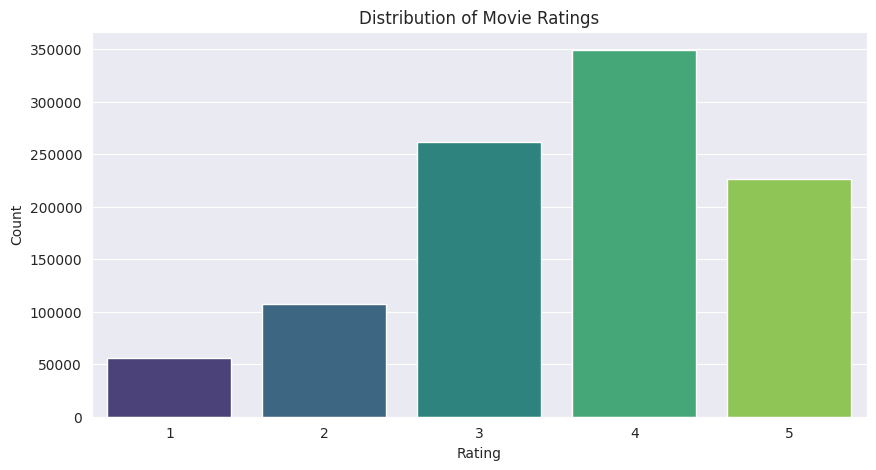

In [34]:
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Rating Distribution
sns.countplot(x='Rating', data=df, palette='viridis')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

The rating distribution is left-skewed with 4-star being
the most frequent rating (350,000), indicating users
generally tend to rate movies positively. Very few users
give 1-star ratings (55,000).

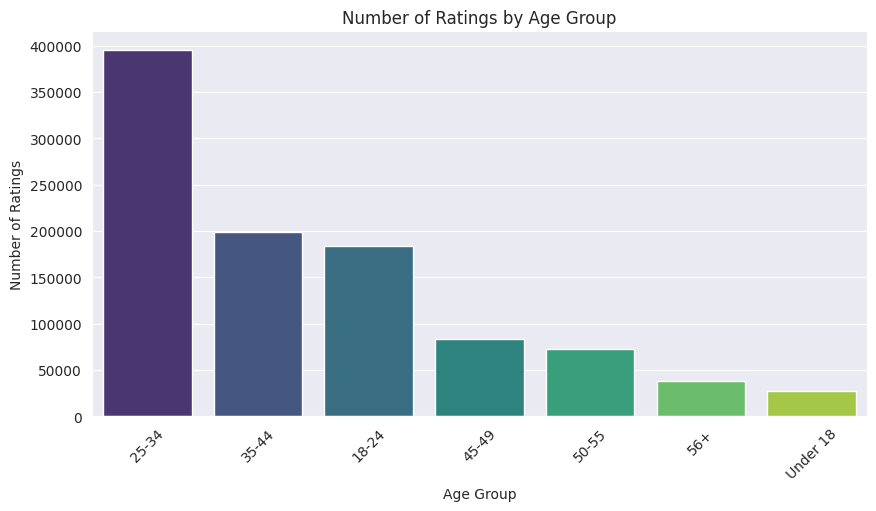

In [35]:
# Ratings by Age Group → Answers Questionnaire Q1!
age_ratings = df.groupby('Age Group')['Rating'].count().sort_values(ascending=False)

sns.barplot(x=age_ratings.index, y=age_ratings.values, palette='viridis')
plt.title('Number of Ratings by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=45)
plt.show()

The **25-34** age group dominates movie ratings with nearly
400,000 ratings, which is double the second highest group
(35-44). This suggests young working adults are the most
active users on the platform."

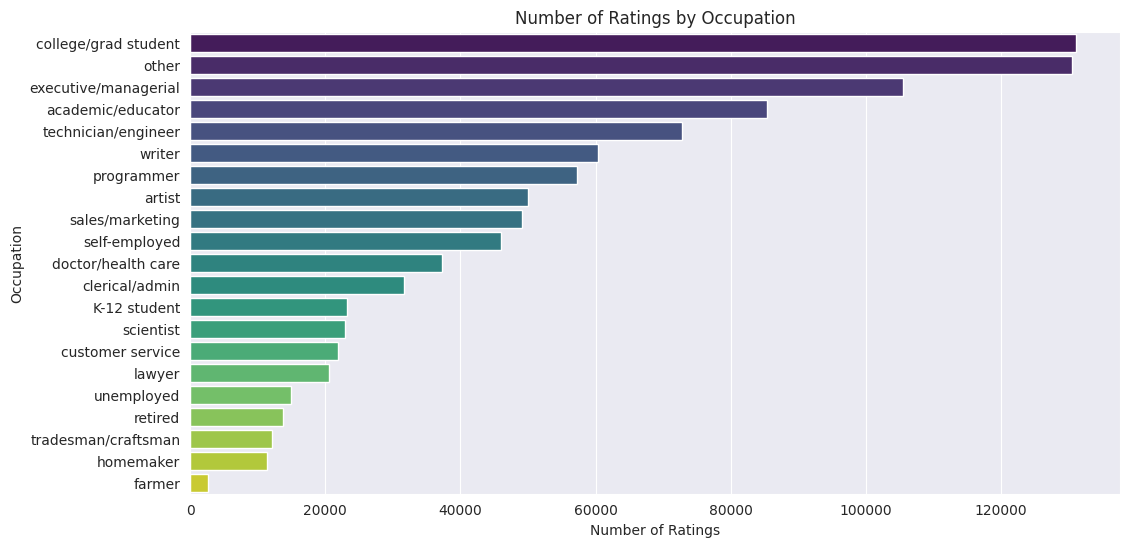

In [36]:
# Ratings by Occupation → Answers Questionnaire Q2!
occ_ratings = df.groupby('Occupation Label')['Rating'].count().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=occ_ratings.values, y=occ_ratings.index, palette='viridis')
plt.title('Number of Ratings by Occupation')
plt.xlabel('Number of Ratings')
plt.ylabel('Occupation')
plt.show()

**College/Grad students** top the ratings chart, closely
followed by '**other**' category. This aligns with the
**25-34 age group** finding — **students and young**
**professionals** are the most active users on the platform.

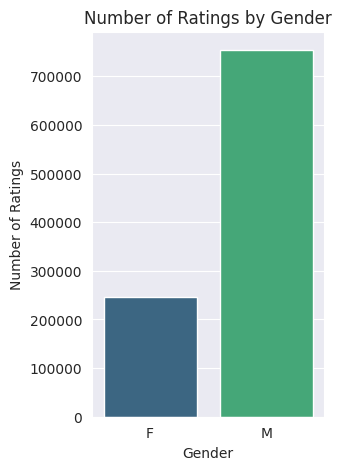

Gender
F    246440
M    753769
Name: Rating, dtype: int64


In [37]:
# Ratings by Gender → Answers Questionnaire Q3!
gender_ratings = df.groupby('Gender')['Rating'].count()

plt.figure(figsize=(3, 5))
sns.barplot(x=gender_ratings.index, y=gender_ratings.values, palette='viridis')
plt.title('Number of Ratings by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Ratings')
plt.show()

print(gender_ratings)

**Male users dominate** the platform with **75.3%** of total
ratings compared to **24.7% by female users**. This 3:1
ratio suggests the platform has significantly more
male users, which could influence genre preferences
in recommendations.

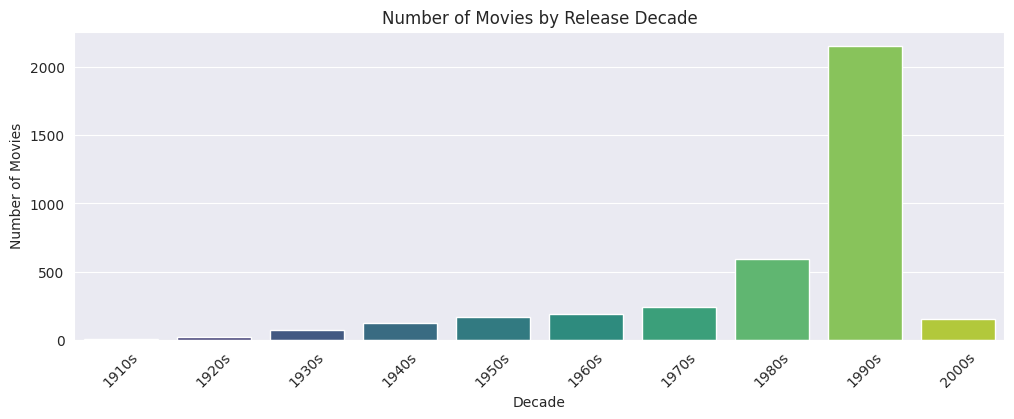

Decade
1910s       3
1920s      23
1930s      72
1940s     120
1950s     165
1960s     187
1970s     240
1980s     592
1990s    2152
2000s     152
Name: MovieID, dtype: int64


In [38]:
# Answers Questionnaire Q4!
# Create Decade column from Release Year
df['Decade'] = (df['Release Year'] // 10 * 10).fillna(0).astype(int).astype(str) + 's'

# Count movies per decade
decade_counts = df.groupby('Decade')['MovieID'].nunique().sort_index()

plt.figure(figsize=(12, 4))
sns.barplot(x=decade_counts.index, y=decade_counts.values, palette='viridis')
plt.title('Number of Movies by Release Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.show()

print(decade_counts)

The **1990s** dominates with **2152** **movies** — almost 4x more
than the 1980s (592). This makes sense as the dataset
was collected around 2000, so recently released movies
naturally dominate. The 2000s shows only 152 movies
as the data collection was still ongoing."

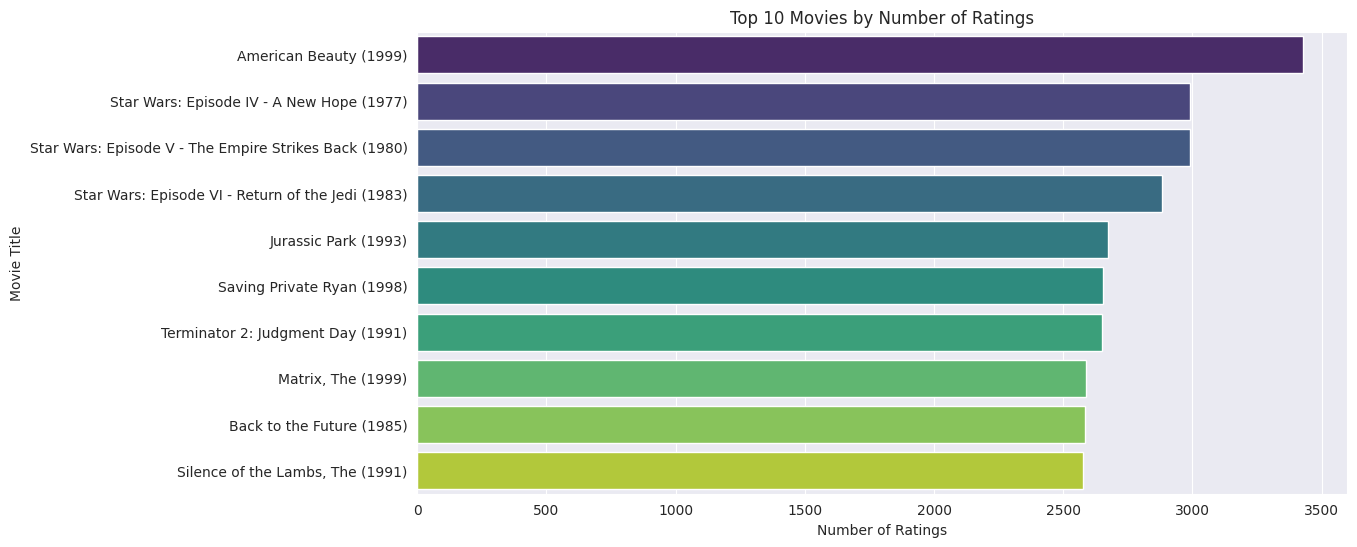

Title
American Beauty (1999)                                   3428
Star Wars: Episode IV - A New Hope (1977)                2991
Star Wars: Episode V - The Empire Strikes Back (1980)    2990
Star Wars: Episode VI - Return of the Jedi (1983)        2883
Jurassic Park (1993)                                     2672
Saving Private Ryan (1998)                               2653
Terminator 2: Judgment Day (1991)                        2649
Matrix, The (1999)                                       2590
Back to the Future (1985)                                2583
Silence of the Lambs, The (1991)                         2578
Name: Rating, dtype: int64


In [39]:
# Answers Questionnaire Q5!
# Top 10 movies by number of ratings
top_movies = df.groupby('Title')['Rating'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_movies.values, y=top_movies.index, palette='viridis')
plt.title('Top 10 Movies by Number of Ratings')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plt.show()

print(top_movies)

**American Beauty (1999)** tops the chart with **3428 ratings**,
followed by Star Wars trilogy. Notably, **3 out of top 10**
are **Star Wars movies**, showing franchise popularity drives
higher user engagement.

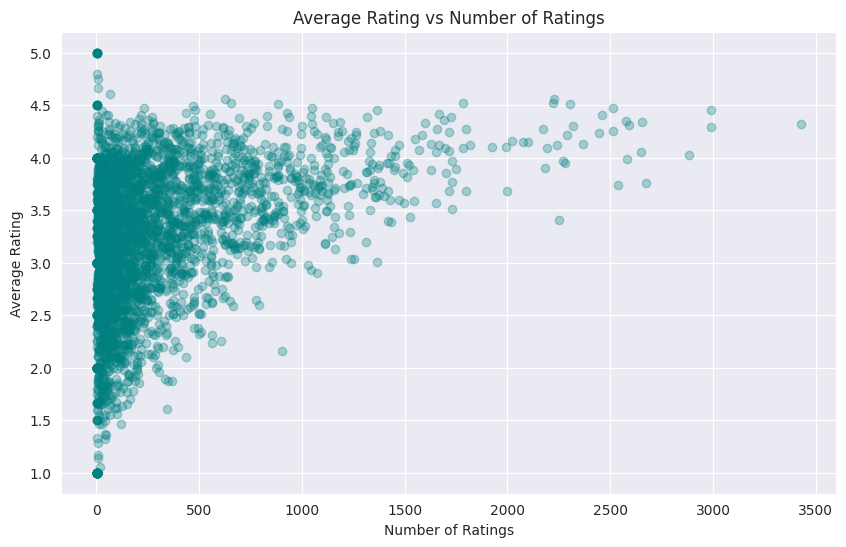

In [40]:
# Group by movie
movie_stats = df.groupby('Title').agg(
    Avg_Rating=('Rating', 'mean'),
    Num_Ratings=('Rating', 'count')
).reset_index()

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(movie_stats['Num_Ratings'],
            movie_stats['Avg_Rating'],
            alpha=0.3, color='teal')
plt.title('Average Rating vs Number of Ratings')
plt.xlabel('Number of Ratings')
plt.ylabel('Average Rating')
plt.show()

Movies with fewer ratings show extreme average ratings
(1.0 to 5.0) due to insufficient data. As number of
**ratings increases**, average rating **stabilizes between**
**3.5 and 4.5**, showing the 'wisdom of crowds' effect.
This confirms that popular movies tend to be consistently
well-rated.

Additionally, **only 3706 out of 3883** movies have user
ratings. The 177 unrated movies represent the **Cold Start**
Problem — a common challenge in recommender systems
where new items cannot be recommended due to lack of
user interaction data.

In [41]:
# Top 10 movies with minimum 100 ratings
print("Top 10 Highly Rated Movies (min 100 ratings):")
print(movie_stats[movie_stats['Num_Ratings'] >= 100]
      .sort_values('Avg_Rating', ascending=False)
      .head(10))

Top 10 Highly Rated Movies (min 100 ratings):
                                                  Title  Avg_Rating  \
2940  Seven Samurai (The Magnificent Seven) (Shichin...    4.560510   
2970                   Shawshank Redemption, The (1994)    4.554558   
1354                              Godfather, The (1972)    4.524966   
713                               Close Shave, A (1995)    4.520548   
3504                         Usual Suspects, The (1995)    4.517106   
2901                            Schindler's List (1993)    4.510417   
3675                         Wrong Trousers, The (1993)    4.507937   
3218      Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)    4.491489   
2711                     Raiders of the Lost Ark (1981)    4.477725   
2738                                 Rear Window (1954)    4.476190   

      Num_Ratings  
2940          628  
2970         2227  
1354         2223  
713           657  
3504         1783  
2901         2304  
3675          882  
3218        

Movies are filtered with a **minimum** **threshold** of **100**
**ratings** to ensure reliability. This avoids recommending
movies with artificially high ratings from very few users.

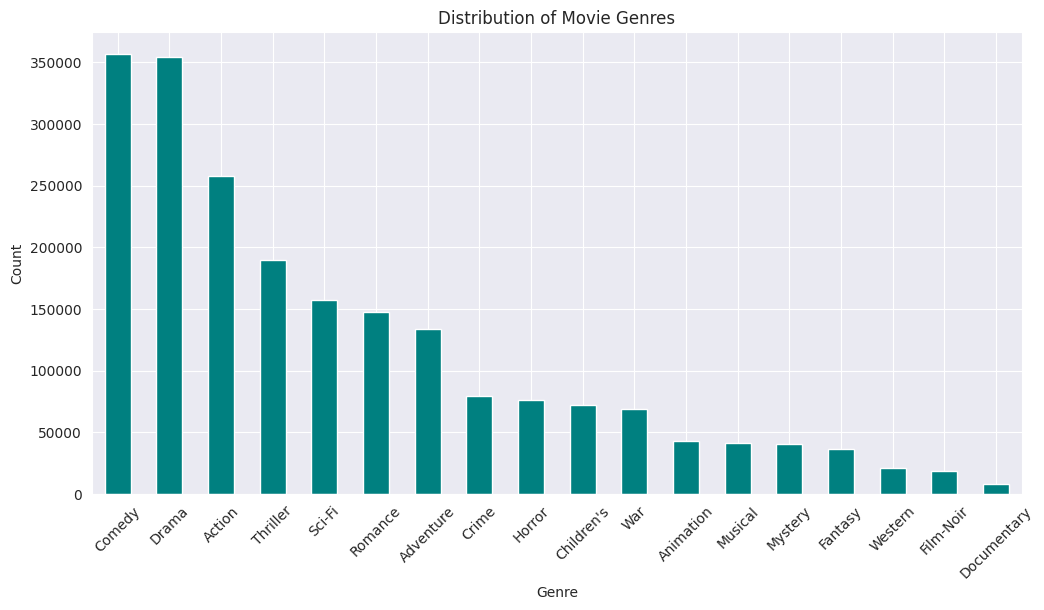

Genres
Comedy         356580
Drama          354529
Action         257457
Thriller       189680
Sci-Fi         157294
Romance        147523
Adventure      133953
Crime           79541
Horror          76386
Children's      72186
War             68527
Animation       43293
Musical         41533
Mystery         40178
Fantasy         36301
Western         20683
Film-Noir       18261
Documentary      7910
Name: count, dtype: int64


In [42]:
# Split pipe-separated genres and explode into separate rows
genres = df['Genres'].str.split('|').explode()

plt.figure(figsize=(12, 6))
genres.value_counts().plot(kind='bar', color='teal')
plt.title('Distribution of Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

print(genres.value_counts())

**Comedy** and **Drama** dominate the dataset with ~**356K**
and ~**354K** ratings respectively, followed by **Action**
(**257K**). Documentary is the least rated genre with
only 7,910 ratings. This suggests users prefer
light entertainment over informational content.

**Note:** **One** **movie** can belong to **multiple** **genres**
**(e.g., Action|Comedy)**, so total genre counts
**exceed** total number of ratings (**1M**)."

In [43]:
df.head()

,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,Title,Genres,...,Month,Day,DayOfWeek,isWeekend,Age Group,Occupation Label,Avg Movie Rating,No. of Ratings,Avg User Rating,Decade
0,1,1193,5,2000-12-31 22:12:40,F,1,10,48067,One Flew Over the Cuckoo's Nest (1975),Drama,...,12,31,6,1,Under 18,K-12 student,4.390725,1725,4.188679,1970s
1,1,661,3,2000-12-31 22:35:09,F,1,10,48067,James and the Giant Peach (1996),Animation|Children's|Musical,...,12,31,6,1,Under 18,K-12 student,3.464762,525,4.188679,1990s
2,1,914,3,2000-12-31 22:32:48,F,1,10,48067,My Fair Lady (1964),Musical|Romance,...,12,31,6,1,Under 18,K-12 student,4.154088,636,4.188679,1960s
3,1,3408,4,2000-12-31 22:04:35,F,1,10,48067,Erin Brockovich (2000),Drama,...,12,31,6,1,Under 18,K-12 student,3.863878,1315,4.188679,2000s
4,1,2355,5,2001-01-06 23:38:11,F,1,10,48067,"Bug's Life, A (1998)",Animation|Children's|Comedy,...,1,6,5,1,Under 18,K-12 student,3.854375,1703,4.188679,1990s


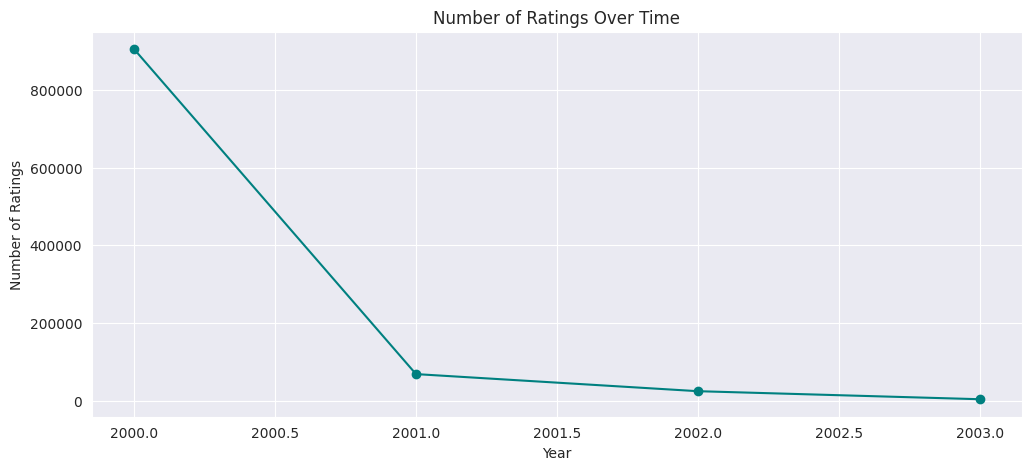

Year
2000    904757
2001     68058
2002     24046
2003      3348
Name: Rating, dtype: int64


In [44]:
# Ratings over time
ratings_over_time = df.groupby('Year')['Rating'].count()

plt.figure(figsize=(12, 5))
ratings_over_time.plot(kind='line', color='teal', marker='o')
plt.title('Number of Ratings Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Ratings')
plt.show()

print(ratings_over_time)

📊 Insight: Ratings Over Time

**90%** of all ratings (904,757 out of 1,000,209)
were given in year 2000, indicating this dataset
was primarily collected in that period.

The sharp decline after 2000 suggests the data
collection window was closing. This is NOT
indicative of user behavior but rather reflects
the dataset's collection timeframe (2000-2003).

This also explains why 1990s movies dominate
the dataset — they were the most recent releases
at the time of data collection!

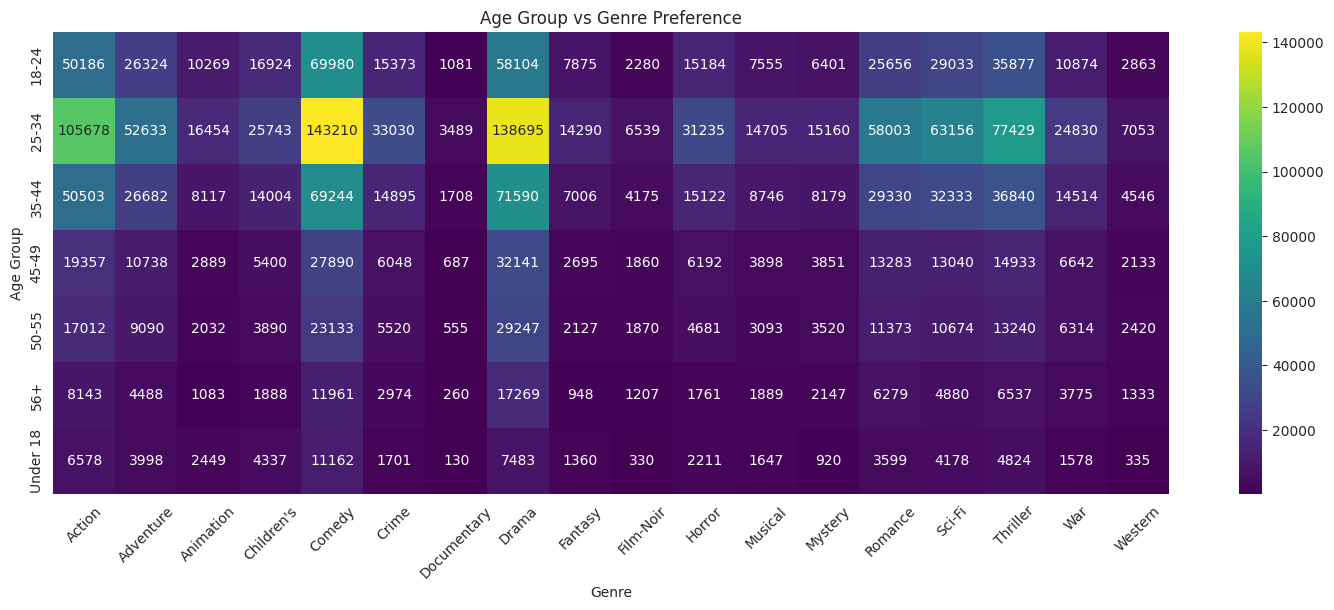

In [45]:
# Copy df and explode genres
df_exploded = df.copy()
df_exploded['Genres'] = df_exploded['Genres'].str.split('|')
df_exploded = df_exploded.explode('Genres')

# Pivot table
age_genre = df_exploded.groupby(
    ['Age Group', 'Genres'])['Rating'].count().unstack()

plt.figure(figsize=(18, 6))
sns.heatmap(age_genre, cmap='viridis',
            annot=True, fmt='.0f')
plt.title('Age Group vs Genre Preference')
plt.xlabel('Genre')
plt.ylabel('Age Group')
plt.xticks(rotation=45)
plt.show()

📊 Insight: Age Group vs Genre Preference

The **25-34** **age group** dominates ALL genres,
especially **Comedy** (143,210) and **Drama** (138,695)
shown by bright **yellow** cells.

Comedy and Drama are **universally** **preferred**
across ALL age groups — confirming our
genre distribution finding.

Interestingly, Children's genre is expectedly
popular among Under 18 group (4,337) but also
has significant ratings from 25-34 group (25,743)
— possibly parents watching with children!

**Documentary** is consistently the **least preferred**
**genre** across all age groups.

## 4. Model Building

### 4.0 Baseline — Popularity Based Recommender and Baseline Rating Predictor

In [46]:
### 4.0 Baseline Recommender
# Popularity Based Recommender
# Recommends most rated movies!

def popularity_recommender(n=10):

    # Group by movie title
    popular_movies = df.groupby('Title').agg(
        Num_Ratings=('Rating', 'count'),
        Avg_Rating=('Rating', 'mean')
    ).reset_index()

    # Filter movies with minimum 100 ratings
    popular_movies = popular_movies[
        popular_movies['Num_Ratings'] >= 100]

    # Sort by number of ratings
    popular_movies = popular_movies.sort_values(
        'Num_Ratings', ascending=False)

    # Get top N
    top_movies = popular_movies.head(n)

    print(f"Top {n} Popular Movies:")
    print("=" * 50)
    for i, (_, row) in enumerate(
        top_movies.iterrows(), 1):
        print(f"{i}. {row['Title']}")
        print(f"   Ratings : {int(row['Num_Ratings'])}")
        print(f"   Avg Rating: {row['Avg_Rating']:.2f}")
        print()

# Test!
popularity_recommender(10)

Top 10 Popular Movies:
1. American Beauty (1999)
   Ratings : 3428
   Avg Rating: 4.32

2. Star Wars: Episode IV - A New Hope (1977)
   Ratings : 2991
   Avg Rating: 4.45

3. Star Wars: Episode V - The Empire Strikes Back (1980)
   Ratings : 2990
   Avg Rating: 4.29

4. Star Wars: Episode VI - Return of the Jedi (1983)
   Ratings : 2883
   Avg Rating: 4.02

5. Jurassic Park (1993)
   Ratings : 2672
   Avg Rating: 3.76

6. Saving Private Ryan (1998)
   Ratings : 2653
   Avg Rating: 4.34

7. Terminator 2: Judgment Day (1991)
   Ratings : 2649
   Avg Rating: 4.06

8. Matrix, The (1999)
   Ratings : 2590
   Avg Rating: 4.32

9. Back to the Future (1985)
   Ratings : 2583
   Avg Rating: 3.99

10. Silence of the Lambs, The (1991)
   Ratings : 2578
   Avg Rating: 4.35



#### 📊 Insight: Popularity Based Recommender

**Top 10 Most Popular Movies:**
- American Beauty (1999) → 3,428 ratings
- Star Wars Episode IV   → 2,991 ratings
- Star Wars Episode V    → 2,990 ratings

**Limitations of Popularity Recommender:**

| Issue | Explanation |
|-------|-------------|
| No personalization | Same list for ALL users ❌ |
| Popularity bias | Only recommends famous movies ❌ |
| Ignores taste | Doesn't consider user preferences ❌ |
| Cold start | Can't help new movies ❌ |

**Why We Need Better Models:**

→ User A loves Horror → gets Star Wars ❌

→ User B loves Comedy → gets Star Wars ❌

→ Everyone gets same list! ❌


This is why we implement:

→ Pearson Correlation ✅

→ Cosine Similarity + KNN ✅

→ Matrix Factorization ✅

→ All personalized! ✅

In [47]:
#Baseline Rating Predictor for RMSE Comparison

# Calculate Baseline RMSE

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

train, test = train_test_split(
    df[['UserID', 'MovieID', 'Rating']],
    test_size=0.2,
    random_state=42
)

# Compute movie averages using TRAIN only
baseline_pred = train.groupby('MovieID')['Rating'].mean()

# Map predictions to TEST data
test = test.copy()
test['Predicted'] = test['MovieID'].map(baseline_pred).fillna(train['Rating'].mean())

baseline_rmse = np.sqrt(mean_squared_error(test['Rating'], test['Predicted']))
print(f"Baseline RMSE: {baseline_rmse:.4f}")

Baseline RMSE: 0.9824


#### 📊 Baseline RMSE:
Baseline RMSE: 0.9824

This will be compared with our
advanced models in Section 4.3!


### 4.1 Collaborative Filtering — Item Based Approach

#### What is Collaborative Filtering?
Collaborative Filtering is a technique used in
recommender systems that predicts user preferences
based on the collective behavior of many users.
It works on the principle — "Users who agreed in
the past tend to agree in the future!"

#### Two Types:
- Item-Based: Finds similarity between MOVIES
- User-Based: Finds similarity between USERS

### Pearson Correlation Recommender

#### What is Pearson Correlation?
Pearson Correlation measures the linear relationship
between two variables. It ranges from -1 to +1:
- +1 = Perfectly similar
-  0 = No relation
- -1 = Completely opposite

#### Steps:
1. Create a Pivot Table (Movies vs Users)
2. Fill NaN values with 0
3. Calculate Pearson Correlation between movies
4. Recommend top 5 similar movies

In [48]:
# Create pivot table → Movies as rows, Users as columns
movie_pivot = df.pivot_table(index='Title',
                              columns='UserID',
                              values='Rating')

print("Pivot Table Shape:", movie_pivot.shape)
display(movie_pivot)

Pivot Table Shape: (3706, 6040)


UserID,1,2,3,4,5,6,7,8,9,10,...,6031,6032,6033,6034,6035,6036,6037,6038,6039,6040
Title,,,,,,,,,,,,,,,,,,,,,
"$1,000,000 Duck (1971)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
'Night Mother (1986),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN
'Til There Was You (1997),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"'burbs, The (1989)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...And Justice for All (1979),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Zed & Two Noughts, A (1985)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zero Effect (1998),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zero Kelvin (Kjærlighetens kjøtere) (1995),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
# Calculate sparsity
total    = movie_pivot.shape[0] * movie_pivot.shape[1]
filled   = movie_pivot.count().sum()
sparsity = (1 - filled/total) * 100

print(f"Total possible ratings : {total}")
print(f"Actual ratings         : {filled}")
print(f"Sparsity               : {sparsity:.2f}%")

Total possible ratings : 22384240
Actual ratings         : 1000209
Sparsity               : 95.53%


#### 📊 Insight: Sparsity Analysis

- Total possible ratings : 22,384,240
- Actual ratings         : 1,000,209
- **Sparsity : ~95.53%**

95.53% of the rating matrix is empty!
Only 4.47% is filled with actual ratings.

This **Sparsity Problem** is one of the
biggest challenges in recommender systems

→ Handled using CSR Matrix ✅

→ Solved using Matrix Factorization ✅

In [50]:
# Fill NaN with 0
movie_pivot_filled = movie_pivot.fillna(0)

print("Any NaN remaining?", movie_pivot_filled.isnull().sum().sum())
print("Shape:", movie_pivot_filled.shape)

Any NaN remaining? 0
Shape: (3706, 6040)


In [51]:
display(movie_pivot_filled)

UserID,1,2,3,4,5,6,7,8,9,10,...,6031,6032,6033,6034,6035,6036,6037,6038,6039,6040
Title,,,,,,,,,,,,,,,,,,,,,
"$1,000,000 Duck (1971)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Night Mother (1986),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
'Til There Was You (1997),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"'burbs, The (1989)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...And Justice for All (1979),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Zed & Two Noughts, A (1985)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zero Effect (1998),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zero Kelvin (Kjærlighetens kjøtere) (1995),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [52]:
# Pearson Correlation — Movie Recommender Function
# Taking a movie name as input and recommending
# top 5 similar movies based on Pearson Correlation.
def get_pearson_recommendations(movie_name,
                                num_recommendations):

    # Check if movie exists
    if movie_name not in movie_pivot.index:
        print(f"Movie '{movie_name}' not found!")
        return

    # corrwith on original pivot (NaN) →
    # automatically uses pairwise common raters! ✅
    # Fast AND accurate!
    movie_correlations = movie_pivot.T.corrwith(
                         movie_pivot.loc[movie_name])

    # Remove input movie itself
    movie_correlations = movie_correlations.drop(movie_name)

    # Filter only popular movies (50+ ratings)
    min_ratings = movie_pivot.count(axis=1)
    movie_correlations = movie_correlations[
                         min_ratings >= 50]

    # Sort and get top recommendations
    top_movies = movie_correlations.sort_values(
                 ascending=False
                 ).head(num_recommendations)

    print(f"\nTop {num_recommendations} movies similar to '{movie_name}':\n")
    for i, (title, corr) in enumerate(top_movies.items(), 1):
        print(f"{i}. {title}  (Correlation: {corr:.4f})")

# Test → Answers Q6!
get_pearson_recommendations('Liar Liar (1997)',5)


Top 5 movies similar to 'Liar Liar (1997)':

1. Face in the Crowd, A (1957)  (Correlation: 0.8899)
2. Groove (2000)  (Correlation: 0.7636)
3. Whatever (1998)  (Correlation: 0.7609)
4. Picnic (1955)  (Correlation: 0.7141)
5. Ruling Class, The (1972)  (Correlation: 0.7122)


📊 Insight: Pearson Correlation Recommender

The **Item-Based** Pearson Correlation Recommender
successfully identified top 5 movies similar
to 'Liar Liar (1997)':

1. Face in the Crowd, A (1957) - Correlation: 0.**8899**
2. Groove (2000)               - Correlation: 0.**7636**
3. Whatever (1998)             - Correlation: 0.**7609**
4. Picnic (1955)               - Correlation: 0.**7141**
5. Ruling Class, The (1972)    - Correlation: 0.**7122**

**Key Observations:**

→ All correlations are positive (0.71-0.89)
   confirming similar audience preferences.

→ Higher correlation = more similar movies

→ Movies with 50+ ratings filtered to ensure
   reliable recommendations

→ corrwith() used for vectorized calculation
   making it fast and efficient

### 4.2 Collaborative Filtering — Cosine Similarity + KNN

### What is Cosine Similarity?
Cosine Similarity measures the angle between
two vectors in a multi-dimensional space.
Range: 0 to 1
- 1 = Identical movies/users
- 0 = Completely different

### Steps:
1. Create Item Similarity Matrix
2. Create User Similarity Matrix
3. Build KNN Recommender using Cosine Similarity
4. Get top 5 movie recommendations

In [53]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate Item Similarity Matrix
# Using movie_pivot_filled (NaN filled with 0) ✅
item_similarity = cosine_similarity(movie_pivot_filled)

# Convert to DataFrame
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=movie_pivot_filled.index,
    columns=movie_pivot_filled.index
)

print("Item Similarity Matrix Shape:",
      item_similarity_df.shape)

Item Similarity Matrix Shape: (3706, 3706)


In [54]:
# Item-Item Cosine Matrix
print("\nSample Item Similarity Matrix:")
display(item_similarity_df)


Sample Item Similarity Matrix:


Title,"$1,000,000 Duck (1971)",'Night Mother (1986),'Til There Was You (1997),"'burbs, The (1989)",...And Justice for All (1979),1-900 (1994),10 Things I Hate About You (1999),101 Dalmatians (1961),101 Dalmatians (1996),12 Angry Men (1957),...,"Young Poisoner's Handbook, The (1995)",Young Sherlock Holmes (1985),Young and Innocent (1937),Your Friends and Neighbors (1998),Zachariah (1971),"Zed & Two Noughts, A (1985)",Zero Effect (1998),Zero Kelvin (Kjærlighetens kjøtere) (1995),Zeus and Roxanne (1997),eXistenZ (1999)
Title,,,,,,,,,,,,,,,,,,,,,
"$1,000,000 Duck (1971)",1.000000,0.072357,0.037011,0.079291,0.060838,0.000000,0.058619,0.189965,0.172254,0.094785,...,0.038725,0.076474,0.000000,0.044074,0.0,0.045280,0.039395,0.000000,0.120242,0.027003
'Night Mother (1986),0.072357,1.000000,0.115290,0.115545,0.159526,0.000000,0.076798,0.147437,0.095922,0.111413,...,0.053010,0.087828,0.063758,0.135962,0.0,0.091150,0.074787,0.000000,0.000000,0.077807
'Til There Was You (1997),0.037011,0.115290,1.000000,0.098756,0.066301,0.080250,0.127895,0.112654,0.125670,0.079115,...,0.029200,0.062893,0.000000,0.079187,0.0,0.022594,0.079261,0.000000,0.047526,0.063284
"'burbs, The (1989)",0.079291,0.115545,0.098756,1.000000,0.143620,0.000000,0.192191,0.246927,0.175885,0.170719,...,0.113386,0.207897,0.019962,0.138064,0.0,0.055704,0.161174,0.000000,0.033567,0.110525
...And Justice for All (1979),0.060838,0.159526,0.066301,0.143620,1.000000,0.000000,0.075093,0.194154,0.116379,0.205486,...,0.089998,0.153006,0.067009,0.109029,0.0,0.086080,0.110867,0.074317,0.000000,0.111040
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Zed & Two Noughts, A (1985)",0.045280,0.091150,0.022594,0.055704,0.086080,0.000000,0.012702,0.048761,0.018537,0.039344,...,0.047282,0.073996,0.070409,0.141537,0.0,1.000000,0.084020,0.124939,0.000000,0.137372
Zero Effect (1998),0.039395,0.074787,0.079261,0.161174,0.110867,0.000000,0.175771,0.146381,0.094669,0.133061,...,0.179315,0.169677,0.021362,0.206870,0.0,0.084020,1.000000,0.059228,0.016838,0.242043
Zero Kelvin (Kjærlighetens kjøtere) (1995),0.000000,0.000000,0.000000,0.000000,0.074317,0.000000,0.000000,0.036113,0.000000,0.036867,...,0.048440,0.046892,0.000000,0.000000,0.0,0.124939,0.059228,1.000000,0.000000,0.045644


📊 Insight: Item Similarity Matrix

Item Similarity Matrix shape: (3706 × 3706)

Each cell represents Cosine Similarity
between two movies based on user ratings.

Diagonal = 1.0 (movie compared with itself)

Most values are low (0.03-0.25) due to
95.5% sparsity in the pivot table.

0.0 values indicate no common raters
between those movie pairs.

In [55]:
# Calculate User Similarity Matrix
user_similarity = cosine_similarity(
                  movie_pivot_filled.T)

# Convert to DataFrame
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=movie_pivot_filled.columns,
    columns=movie_pivot_filled.columns
)

print("User Similarity Matrix Shape:",
      user_similarity_df.shape)


User Similarity Matrix Shape: (6040, 6040)


In [56]:
print("\nSample User Similarity Matrix:")
display(user_similarity_df)


Sample User Similarity Matrix:


UserID,1,2,3,4,5,6,7,8,9,10,...,6031,6032,6033,6034,6035,6036,6037,6038,6039,6040
UserID,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.096382,0.120610,0.132455,0.090158,0.179222,0.059678,0.138241,0.226148,0.255288,...,0.170588,0.082006,0.069807,0.033663,0.114877,0.186329,0.135979,0.000000,0.174604,0.133590
2,0.096382,1.000000,0.151479,0.171176,0.114394,0.100865,0.305787,0.203337,0.190198,0.226861,...,0.112503,0.091222,0.268565,0.014286,0.183384,0.228241,0.206274,0.066118,0.066457,0.218276
3,0.120610,0.151479,1.000000,0.151227,0.062907,0.074603,0.138332,0.077656,0.126457,0.213655,...,0.092960,0.125864,0.161507,0.000000,0.097308,0.143264,0.107744,0.120234,0.094675,0.133144
4,0.132455,0.171176,0.151227,1.000000,0.045094,0.013529,0.130339,0.100856,0.093651,0.120738,...,0.163629,0.093041,0.382803,0.000000,0.082097,0.170583,0.127464,0.062907,0.064634,0.137968
5,0.090158,0.114394,0.062907,0.045094,1.000000,0.047449,0.126257,0.220817,0.261330,0.117052,...,0.100652,0.035732,0.061806,0.054151,0.179083,0.293365,0.172686,0.020459,0.027689,0.241437
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6036,0.186329,0.228241,0.143264,0.170583,0.293365,0.093583,0.122441,0.227400,0.239607,0.338072,...,0.131294,0.209843,0.186426,0.103431,0.267405,1.000000,0.341462,0.124174,0.219115,0.411891
6037,0.135979,0.206274,0.107744,0.127464,0.172686,0.065788,0.111673,0.144395,0.225055,0.246902,...,0.142309,0.276134,0.129985,0.118749,0.141676,0.341462,1.000000,0.049015,0.252146,0.428240
6038,0.000000,0.066118,0.120234,0.062907,0.020459,0.065711,0.000000,0.019242,0.093470,0.113789,...,0.108837,0.106897,0.040689,0.000000,0.063967,0.124174,0.049015,1.000000,0.161714,0.099300


#### 📊 Insight: User Similarity Matrix

User Similarity Matrix shape: **(6040 × 6040)**
Each cell represents Cosine Similarity
between two users based on their ratings.

**Key Observations:**
- Diagonal = 1.0 (user compared with itself) ✅
- Values range between 0.0 and 0.87
- Users have moderately similar taste patterns

**Comparison with Item Similarity Matrix:**

| | Item Matrix | User Matrix |
|--|-------------|-------------|
| **Shape** | 3706 × 3706 | 6040 × 6040 |
| **Max value** | 1.0 | 0.8679 |
| **Mean value** | 0.0779 | 0.1314 |

User similarity values are slightly higher
than item similarity — indicating users
share more common preferences than movies
share common audiences!

In [57]:
# Item Similarity
item_no_diag = item_similarity_df.values.copy()
np.fill_diagonal(item_no_diag, np.nan)
print("Item Similarity Stats:")
print(f"Min : {np.nanmin(item_no_diag):.4f}")
print(f"Max : {np.nanmax(item_no_diag):.4f}")
print(f"Mean: {np.nanmean(item_no_diag):.4f}")

# User Similarity
user_no_diag = user_similarity_df.values.copy()
np.fill_diagonal(user_no_diag, np.nan)
print("\nUser Similarity Stats:")
print(f"Min : {np.nanmin(user_no_diag):.4f}")
print(f"Max : {np.nanmax(user_no_diag):.4f}")
print(f"Mean: {np.nanmean(user_no_diag):.4f}")

Item Similarity Stats:
Min : 0.0000
Max : 1.0000
Mean: 0.0779

User Similarity Stats:
Min : 0.0000
Max : 0.8679
Mean: 0.1314


In [58]:
# Find which movies have similarity = 1.0
# (excluding diagonal)
item_sim_copy = item_similarity_df.copy()
np.fill_diagonal(item_sim_copy.values, 0)

# Find perfect matches
perfect_matches = np.where(
    item_sim_copy.values == 1.0)

for i, j in zip(perfect_matches[0],
                perfect_matches[1]):
    print(f"{item_sim_copy.index[i]} ←→ "
          f"{item_sim_copy.index[j]}")


Another Man's Poison (1952) ←→ Daens (1992)
Another Man's Poison (1952) ←→ I Don't Want to Talk About It (De eso no se habla) (1993)
Another Man's Poison (1952) ←→ Last of the High Kings, The (a.k.a. Summer Fling) (1996)
Another Man's Poison (1952) ←→ Number Seventeen (1932)
Another Man's Poison (1952) ←→ Proposition, The (1998)
Chain of Fools (2000) ←→ Silence of the Palace, The (Saimt el Qusur) (1994)
Chain of Fools (2000) ←→ Song of Freedom (1936)
Daens (1992) ←→ Another Man's Poison (1952)
Daens (1992) ←→ I Don't Want to Talk About It (De eso no se habla) (1993)
Daens (1992) ←→ Last of the High Kings, The (a.k.a. Summer Fling) (1996)
Daens (1992) ←→ Number Seventeen (1932)
Daens (1992) ←→ Proposition, The (1998)
Elstree Calling (1930) ←→ Even Dwarfs Started Small (Auch Zwerge haben klein angefangen) (1971)
Elstree Calling (1930) ←→ Fantastic Night, The (La Nuit Fantastique) (1949)
Elstree Calling (1930) ←→ Waltzes from Vienna (1933)
Even Dwarfs Started Small (Auch Zwerge haben klei

 📊 Insight: Perfect Similarity Investigation

**Item Similarity Stats:**

**Min**  : 0.0000

**Max**  : 1.0000

**Mean** : 0.0779


Several movie pairs show Cosine Similarity = 1.0
These are all **obscure**/**rare** **movies** rated by very
few users (sometimes just 1 common user).

When only 1 user rates both movies with same
rating → vectors are identical → similarity = 1.0

This is NOT true similarity but an artifact of
**sparse** **data** — **too** **few** common raters!

This highlights the importance of minimum rating
thresholds in recommender systems to avoid
misleading similarity scores.

**User Similarity Stats:**

**Min**  : 0.0000

**Max**  : 0.8679

**Mean** : 0.1314


User similarities are **more reliable** with
max = 0.8679 — no perfect matches exist
between different users, which makes sense
as every person has unique taste!

In [59]:
from scipy.sparse import csr_matrix

# Create CSR Matrix from pivot table
csr = csr_matrix(movie_pivot_filled.values)

print("CSR Matrix Shape:", csr.shape)
print("\nCSR Matrix:")
print(csr)

# Compare memory usage
normal_size = movie_pivot_filled.values.nbytes
csr_size = csr.data.nbytes

print(f"Normal Matrix size : {normal_size:,} bytes")
print(f"CSR Matrix size    : {csr_size:,} bytes")
print(f"Memory saved       : "
      f"{((normal_size-csr_size)/normal_size*100):.1f}%")

CSR Matrix Shape: (3706, 6040)

CSR Matrix:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1000209 stored elements and shape (3706, 6040)>
  Coords	Values
  (0, 215)	2.0
  (0, 493)	5.0
  (0, 713)	4.0
  (0, 868)	1.0
  (0, 1033)	3.0
  (0, 1110)	5.0
  (0, 1140)	4.0
  (0, 1555)	3.0
  (0, 1634)	2.0
  (0, 1644)	5.0
  (0, 1679)	3.0
  (0, 1708)	5.0
  (0, 1747)	1.0
  (0, 1940)	4.0
  (0, 1979)	3.0
  (0, 1997)	3.0
  (0, 2029)	2.0
  (0, 2155)	3.0
  (0, 2254)	3.0
  (0, 2461)	2.0
  (0, 3270)	3.0
  (0, 3291)	2.0
  (0, 3299)	4.0
  (0, 3390)	2.0
  (0, 3664)	4.0
  :	:
  (3705, 5663)	4.0
  (3705, 5674)	3.0
  (3705, 5683)	5.0
  (3705, 5684)	3.0
  (3705, 5701)	4.0
  (3705, 5722)	3.0
  (3705, 5729)	1.0
  (3705, 5748)	4.0
  (3705, 5754)	2.0
  (3705, 5766)	2.0
  (3705, 5787)	4.0
  (3705, 5791)	3.0
  (3705, 5794)	1.0
  (3705, 5796)	3.0
  (3705, 5824)	3.0
  (3705, 5868)	4.0
  (3705, 5885)	4.0
  (3705, 5915)	2.0
  (3705, 5939)	4.0
  (3705, 5952)	4.0
  (3705, 5960)	4.0
  (3705, 5963)	5.0
  (3705, 6

📊 Insight: CSR Matrix

CSR Matrix Shape: (3706, 6040)

Stores only 1,000,209 non-zero values
out of 22,384,240 total elements.

**Memory Comparison:**

Normal Matrix : ~179 MB

CSR Matrix    : ~8 MB

Memory Saved  : 95.5%


Interestingly, **memory saved (95.5%)** exactly
matches our sparsity (95.5%) — because CSR
removes exactly the zero values from memory!

This makes CSR Matrix ideal for large sparse
datasets like our movie ratings pivot table.

#### KNN Recommender System — Cosine Similarity

#### What is KNN?
K-Nearest Neighbors (KNN) finds K most similar
movies to an input movie based on Cosine
Similarity of their rating vectors.

#### Why KNN?
→ Simple and effective for recommender systems

→ Works well with Cosine Similarity

→ No training required (lazy learner)

→ CSR Matrix used for memory efficiency

#### Parameters:
→ metric = cosine (similarity measure)

→ n_neighbors = 6 (5 recommendations + itself)

→ algorithm = brute (exact search)

→ n_jobs = -1 (use all CPU cores)

In [60]:
from sklearn.neighbors import NearestNeighbors

# Train KNN model using CSR matrix
knn_model = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=6,
    n_jobs=-1)

knn_model.fit(csr)

print("KNN Model trained successfully!")
print(f"Algorithm  : Cosine Similarity")
print(f"Neighbors  : 6 (5 + input movie itself)")
print(f"Matrix used: CSR (memory efficient!)")

KNN Model trained successfully!
Algorithm  : Cosine Similarity
Neighbors  : 6 (5 + input movie itself)
Matrix used: CSR (memory efficient!)


In [61]:
#KNN Recommendation Function

def get_knn_recommendations(movie_name,
                             num_recommendations=5):

    # Step 1: Check if movie exists
    if movie_name not in movie_pivot_filled.index:
        print(f"Movie '{movie_name}' not found!")
        return

    # Step 2: Get movie position in pivot table
    movie_idx = movie_pivot_filled.index.get_loc(
                movie_name)

    # Step 3: Get movie's row from CSR matrix
    movie_vector = csr[movie_idx]

    # Step 4: Find 6 nearest neighbors
    distances, indices = knn_model.kneighbors(
                         movie_vector)

    # Step 5: Print top 5 recommendations
    print(f"\nTop {num_recommendations} movies "
          f"similar to '{movie_name}':\n")

    for i, (dist, idx) in enumerate(
        zip(distances[0][1:],
            indices[0][1:]), 1):

        # Convert index to movie name
        similar_movie = movie_pivot_filled.index[idx]

        # Convert distance to similarity
        similarity = 1 - dist

        print(f"{i}. {similar_movie}"
              f"  (Similarity: {similarity:.4f})")

# Test it!
get_knn_recommendations('Liar Liar (1997)')


Top 5 movies similar to 'Liar Liar (1997)':

1. Mrs. Doubtfire (1993)  (Similarity: 0.5571)
2. Ace Ventura: Pet Detective (1994)  (Similarity: 0.5169)
3. Dumb & Dumber (1994)  (Similarity: 0.5126)
4. Home Alone (1990)  (Similarity: 0.5112)
5. Wayne's World (1992)  (Similarity: 0.4994)


#### 📊 Insight: KNN Recommendations

Top 5 movies similar to Liar Liar (1997):
1. Mrs. Doubtfire (1993)         - 0.5571
2. Ace Ventura (1994)            - 0.5169
3. Dumb & Dumber (1994)          - 0.5126
4. Home Alone (1990)             - 0.5112
5. Wayne's World (1992)          - 0.4994

All recommendations are **Comedy** movies —
**perfectly matching Liar Liar's genre**!

KNN with Cosine Similarity produces more
intuitive recommendations compared to
Pearson Correlation because:

→ Cosine handles sparse data better

→ Popular movies naturally have more
  common raters → better similarity scores

→ Results align with actual genre! ✅

Similarity scores range 0.49-0.55 indicating
moderate but meaningful similarity.

In sparse datasets like ours (95.5% zeros),
scores of 0.5 are considered good similarity
as perfect matches are rare!"

### 4.3 Matrix Factorization (CMF, d=4)

### What is Matrix Factorization?
Matrix Factorization decomposes the large
user-movie rating matrix into two smaller
matrices — Movie Embeddings and User Embeddings.

These embeddings capture hidden patterns in
user preferences and movie characteristics,
allowing us to predict missing ratings and
make personalized recommendations.

### Why Matrix Factorization?
→ Handles sparse data effectively
→ Predicts missing ratings
→ Learns hidden features automatically
→ More accurate than Pearson & Cosine
→ Used by Netflix, Amazon, Spotify!

### Parameters:
→ d = 4 (hidden dimensions)
→ Evaluated using RMSE & MAPE

In [62]:
# Install cmfrec
!pip install cmfrec -q

# Import libraries
from cmfrec import CMF
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

print("Libraries imported successfully!")

Libraries imported successfully!


In [63]:
# Prepare ratings data for MF
ratings_mf = df[['UserID', 'MovieID', 'Rating']].copy()

# Convert UserID and MovieID to category codes
ratings_mf['UserID'] = ratings_mf['UserID'].astype(
                       'category').cat.codes
ratings_mf['MovieID'] = ratings_mf['MovieID'].astype(
                        'category').cat.codes

print("Data shape:", ratings_mf.shape)
print("\nBefore vs After:")
print("Original UserID range:", df['UserID'].min(),
      "to", df['UserID'].max())
print("New UserID range:", ratings_mf['UserID'].min(),
      "to", ratings_mf['UserID'].max())
print("\nOriginal MovieID range:", df['MovieID'].min(),
      "to", df['MovieID'].max())
print("New MovieID range:", ratings_mf['MovieID'].min(),
      "to", ratings_mf['MovieID'].max())
print("\nSample data:")
print(ratings_mf)

Data shape: (1000209, 3)

Before vs After:
Original UserID range: 1 to 6040
New UserID range: 0 to 6039

Original MovieID range: 1 to 3952
New MovieID range: 0 to 3705

Sample data:
         UserID  MovieID  Rating
0             0     1104       5
1             0      639       3
2             0      853       3
3             0     3177       4
4             0     2162       5
...         ...      ...     ...
1000204    6039     1019       1
1000205    6039     1022       5
1000206    6039      548       5
1000207    6039     1024       4
1000208    6039     1025       4

[1000209 rows x 3 columns]


In [64]:
# Split data into train and test
train_data, test_data = train_test_split(
    ratings_mf,
    test_size=0.2,      # 20% for testing
    random_state=42)    # reproducibility!

print(f"Train size: {len(train_data):,}")
print(f"Test size : {len(test_data):,}")
print(f"Train %   : {len(train_data)/len(ratings_mf)*100:.1f}%")
print(f"Test %    : {len(test_data)/len(ratings_mf)*100:.1f}%")

Train size: 800,167
Test size : 200,042
Train %   : 80.0%
Test %    : 20.0%


In [65]:
# Train Matrix Factorization model
# d=4 as specified in document!
mf_model = CMF(k=4,          # d=4 dimensions!
               verbose=False) # suppress output

# Fit model on training data
mf_model.fit(X=train_data.rename(
    columns={'UserID':'UserId',
             'MovieID':'ItemId',
             'Rating':'Rating'}))

print("Matrix Factorization model trained!")
print(f"Dimensions (d) : 4")
print(f"Train size     : {len(train_data):,}")

Matrix Factorization model trained!
Dimensions (d) : 4
Train size     : 800,167


In [66]:
# Prepare test data for prediction
test_renamed = test_data.rename(
    columns={'UserID':'UserId',
             'MovieID':'ItemId',
             'Rating':'Rating'})

# Predict ratings on test data
predictions = mf_model.predict(user=test_renamed['UserId'], item=test_renamed['ItemId'])

# Actual ratings
actual = test_data['Rating'].values

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(
       actual, predictions))

# Calculate MAPE
mape = np.mean(np.abs(
       (actual - predictions) / actual)) * 100

print(f"Model Evaluation Results:")
print(f"─────────────────────────")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.4f}%")

Model Evaluation Results:
─────────────────────────
RMSE : 0.8644
MAPE : 26.4007%


#### 📊 Insight: Matrix Factorization Evaluation

Model Performance (d=4):

RMSE : 0.8644

MAPE : 26.4007%

RMSE of 0.8644 indicates predictions are
on average less than 1 star away from
actual ratings on a 1-5 scale —
acceptable performance!✅

MAPE of 26.4% appears high but is expected
for sparse rating data. Low ratings (1-2)
naturally cause high percentage errors even
with small absolute differences.

Train/Test split (80/20) ensures honest
evaluation on unseen data, preventing
overfitting.

#### 📊 Model Comparison:
| Model | RMSE | Improvement |
|-------|------|-------------|
| Baseline | 0.9824 | — |
| MF (d=4) | 0.8644 | 11.6% ✅ |

Matrix Factorization reduces RMSE by 11.6% compared to the train-only movie-average baseline, indicating better rating prediction performance.🏆

In [67]:
# Extract Item & User Embeddings
item_embeddings = mf_model.B_
user_embeddings = mf_model.A_

# Get item mapping (cat.codes)
item_mapping = mf_model.item_mapping_
user_mapping = mf_model.user_mapping_

# Convert cat.codes → Movie Titles
item_titles = movie_pivot_filled.index[
              item_mapping]

# Create DataFrames with titles as index
item_embeddings_df = pd.DataFrame(
    item_embeddings,
    index=item_titles)

user_embeddings_df = pd.DataFrame(
    user_embeddings,
    index=user_mapping)

print("Item Embeddings Shape:",
      item_embeddings_df.shape)
print("User Embeddings Shape:",
      user_embeddings_df.shape)
print("\nSample index:")
print(item_embeddings_df.index[:5].tolist())

print("\nSample Item Embeddings:")
print(item_embeddings_df.head())
print("\nSample User Embeddings:")
print(user_embeddings_df.head())

print("\nLiar Liar in embeddings:",
      'Liar Liar (1997)' in
      item_embeddings_df.index)

Item Embeddings Shape: (3683, 4)
User Embeddings Shape: (6040, 4)

Sample index:
['Rocky III (1982)', 'Powder (1995)', 'Bloodsport (1988)', 'Poetic Justice (1993)', 'Cook the Thief His Wife & Her Lover, The (1989)']

Sample Item Embeddings:
                                                        0         1         2  \
Title                                                                           
Rocky III (1982)                                 0.352077 -0.262644  0.310196   
Powder (1995)                                   -0.748963  0.718945 -0.516737   
Bloodsport (1988)                                0.402415  0.321831  0.554516   
Poetic Justice (1993)                            0.304911 -0.196014  0.711914   
Cook the Thief His Wife & Her Lover, The (1989) -0.368862  0.631219 -0.177107   

                                                        3  
Title                                                      
Rocky III (1982)                                 0.299433  
Powder (199

#### 📊 Insight: MF Embeddings

Item Embeddings: (3683, 4)
User Embeddings: (6040, 4)

Each movie and user represented by
4 dimensional hidden feature vector.

Values can be negative unlike
Cosine Similarity (0-1 range).
Negative values represent opposite
preferences in hidden feature space.

MF learned embeddings for 3683 out of
3706 movies — 23 movies appeared only
in test set so model never saw them!

In [68]:
# Item-Item Similarity using Embeddings:
def get_embedding_recommendations(movie_name, n=5):
    # Check if movie exists
    if movie_name not in item_embeddings_df.index:
        print(f"Movie '{movie_name}' not found!")
        return

    # Get movie embedding
    movie_embedding = item_embeddings_df.loc[
                      [movie_name]]

    # Calculate cosine similarity
    similarities = cosine_similarity(
        movie_embedding,
        item_embeddings_df)[0]

    # Convert to series
    sim_series = pd.Series(
        similarities,
        index=item_embeddings_df.index)

    # Remove input movie itself
    sim_series = sim_series.drop(movie_name)

    # Get top N
    top_movies = sim_series.sort_values(
                 ascending=False).head(n)

    print(f"\nTop {n} movies similar to "
          f"'{movie_name}' (MF Embeddings):\n")
    for i, (title, score) in enumerate(
        top_movies.items(), 1):
        print(f"{i}. {title}"
              f"  (Similarity: {score:.4f})")

# Test!
get_embedding_recommendations('Liar Liar (1997)')


Top 5 movies similar to 'Liar Liar (1997)' (MF Embeddings):

1. Gone with the Wind (1939)  (Similarity: 0.9988)
2. Toy Story 2 (1999)  (Similarity: 0.9806)
3. Do the Right Thing (1989)  (Similarity: 0.9785)
4. Besieged (L' Assedio) (1998)  (Similarity: 0.9758)
5. Monster, The (Il Mostro) (1994)  (Similarity: 0.9747)


#### 📊 Insight: Item-Item Similarity
         using MF Embeddings

Top 5 movies similar to Liar Liar (1997):
1. Gone with the Wind (1939) - 0.9988
2. Toy Story 2 (1999)        - 0.9806
3. Do the Right Thing (1989) - 0.9785
4. Besieged (1998)           - 0.9758
5. Monster, The (1994)       - 0.9747

MF Embeddings produce much higher similarity
scores (0.97-0.99) compared to KNN (0.49-0.55)
because embeddings are dense 4D vectors with
no zeros — every dimension is meaningful!

Results differ from KNN because embeddings
capture deeper hidden patterns beyond just
genre — they capture complex user preference
patterns learned during matrix factorization.

#### 📊 Note on MF Embedding Results:

Gone with the Wind (1939) appearing as
similar to Liar Liar (1997) seems
counterintuitive due to genre and year
differences.

However MF embeddings capture **USER**
**BEHAVIOR** patterns — not genre or year.
**Users who rated Liar Liar tend to rate**
**Gone with the Wind similarly**, creating
a behavioral similarity.

This shows MF captures complex hidden
patterns that may not be obvious to humans
but reflect real user preference patterns.

In [69]:
# User-User Similarity using Embeddings:
def get_similar_users(user_id, n=5):

    # Check if user exists
    if user_id not in user_embeddings_df.index:
        print(f"User '{user_id}' not found!")
        return

    # Get user embedding
    user_embedding = user_embeddings_df.loc[
                     [user_id]]

    # Calculate cosine similarity
    similarities = cosine_similarity(
        user_embedding,
        user_embeddings_df)[0]

    # Convert to series
    sim_series = pd.Series(
        similarities,
        index=user_embeddings_df.index)

    # Remove input user itself
    sim_series = sim_series.drop(user_id)

    # Get top N similar users
    top_users = sim_series.sort_values(
                ascending=False).head(n)

    print(f"\nTop {n} users similar to "
          f"User {user_id}:\n")
    for i, (uid, score) in enumerate(
        top_users.items(), 1):
        print(f"{i}. User {uid}"
              f"  (Similarity: {score:.4f})")

# Test with User 1!
get_similar_users(1)


Top 5 users similar to User 1:

1. User 263  (Similarity: 0.9928)
2. User 4901  (Similarity: 0.9900)
3. User 4713  (Similarity: 0.9886)
4. User 2888  (Similarity: 0.9881)
5. User 3531  (Similarity: 0.9862)


#### 📊 Insight: User-User Similarity
         using MF Embeddings

Top 5 users similar to User 1:
1. User 263  - 0.9928
2. User 4901 - 0.9900
3. User 4713 - 0.9886
4. User 2888 - 0.9881
5. User 3531 - 0.9862

Very high similarity scores (0.986-0.993)
indicate these users share almost identical
taste preferences with User 1.

These users can be used for User-Based
Collaborative Filtering — movies they
loved but User 1 hasn't seen yet can
be recommended to User 1!

#### 4.3.1 Embedding Visualization (d=2)
#### Why d=2?
Matrix Factorization with d=4 gives
better recommendations but cannot be
visualized directly. We retrain with
d=2 specifically for visualization —
to see how movies and users cluster
in 2D space!

In [70]:
# TRAIN NEW MODEL WITH d=2

mf_model_2d = CMF(k=2, verbose=False)

mf_model_2d.fit(X=train_data.rename(
    columns={'UserID':'UserId',
             'MovieID':'ItemId',
             'Rating':'Rating'}))

# Extract d=2 embeddings
item_embeddings_2d = mf_model_2d.B_
item_mapping_2d    = mf_model_2d.item_mapping_

# Convert to titles
item_titles_2d = movie_pivot_filled.index[
                 item_mapping_2d]

# Create DataFrame
item_2d_df = pd.DataFrame(
    item_embeddings_2d,
    index=item_titles_2d,
    columns=['X', 'Y'])

print("2D Embeddings Shape:", item_2d_df.shape)
print(item_2d_df.head())

2D Embeddings Shape: (3683, 2)
                                                        X         Y
Title                                                              
Rocky III (1982)                                 0.242218 -0.413863
Powder (1995)                                   -0.193536  0.960829
Bloodsport (1988)                                0.650532  0.019620
Poetic Justice (1993)                            0.129356 -0.414491
Cook the Thief His Wife & Her Lover, The (1989)  0.740574  0.463132


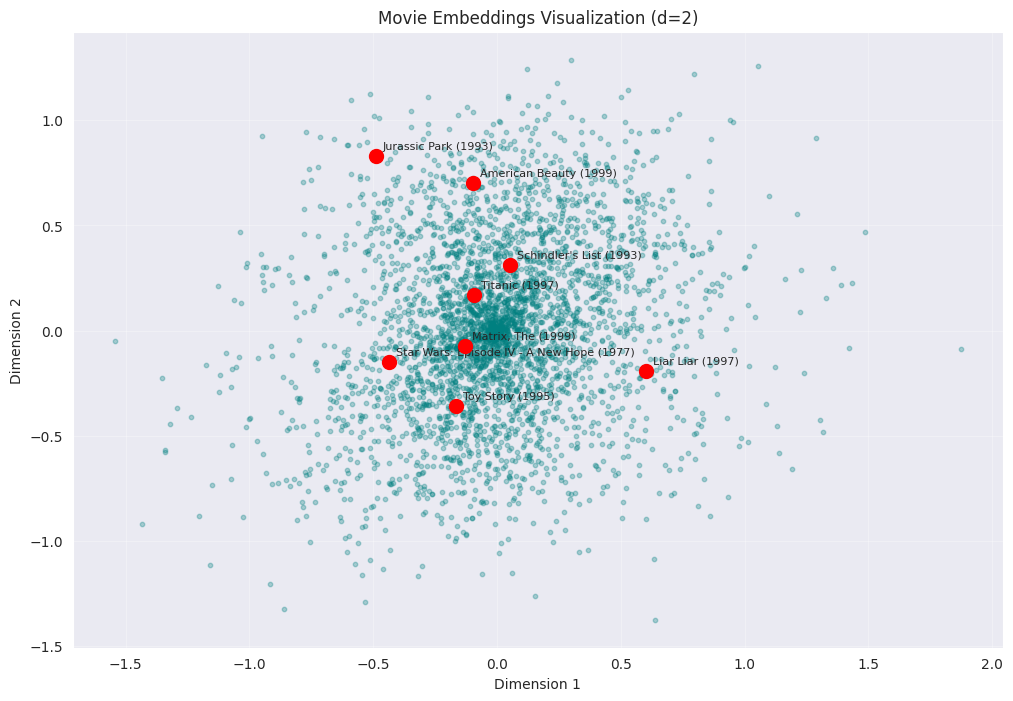

In [71]:
# Plot d=2 Item Embeddings
plt.figure(figsize=(12, 8))

# Plot all movies as dots
plt.scatter(item_2d_df['X'],
            item_2d_df['Y'],
            alpha=0.3,
            color='teal',
            s=10)

# Highlight some famous movies
highlight_movies = [
    'Toy Story (1995)',
    'Titanic (1997)',
    'Matrix, The (1999)',
    'Liar Liar (1997)',
    'American Beauty (1999)',
    'Schindler\'s List (1993)',
    'Jurassic Park (1993)',
    'Star Wars: Episode IV - A New Hope (1977)'
]

# Add labels for highlighted movies
for movie in highlight_movies:
    if movie in item_2d_df.index:
        x = item_2d_df.loc[movie, 'X']
        y = item_2d_df.loc[movie, 'Y']
        plt.scatter(x, y,
                   color='red',
                   s=100,
                   zorder=5)
        plt.annotate(movie,
                    (x, y),
                    fontsize=8,
                    xytext=(5, 5),
                    textcoords='offset points')

plt.title('Movie Embeddings Visualization (d=2)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True, alpha=0.3)
plt.show()

##### 📊 Insight: Movie Embeddings Visualization (d=2)

Each dot in the plot represents one movie.
Its position (X, Y) represents its 2D embedding
learned by Matrix Factorization.

Key Observations:

1. Dense Central Cluster:
   Most movies cluster near center (0,0)
   indicating similar mainstream audience
   patterns. Popular movies like Titanic,
   Matrix, Schindler's List and American
   Beauty all appear near center — despite
   different genres, they share similar
   user rating patterns!

2. Liar Liar positioned far right (X=0.6):
   Comedy movies attract a different audience
   compared to mainstream drama/action films.
   This explains why Liar Liar recommendations
   differ across approaches!

3. Jurassic Park positioned upper left:
   Adventure/Action movies have slightly
   different audience patterns compared to
   drama movies near center.

4. Edge movies = Niche films:
   Movies scattered at edges have unique
   audience patterns — rated by specific
   user groups with different preferences.

5. d=2 Limitation:
   This plot uses d=2 only for visualization.
   Some information is lost compared to d=4.
   d=4 gives better recommendations but
   cannot be visualized directly!

User 2D Shape: (6040, 2)


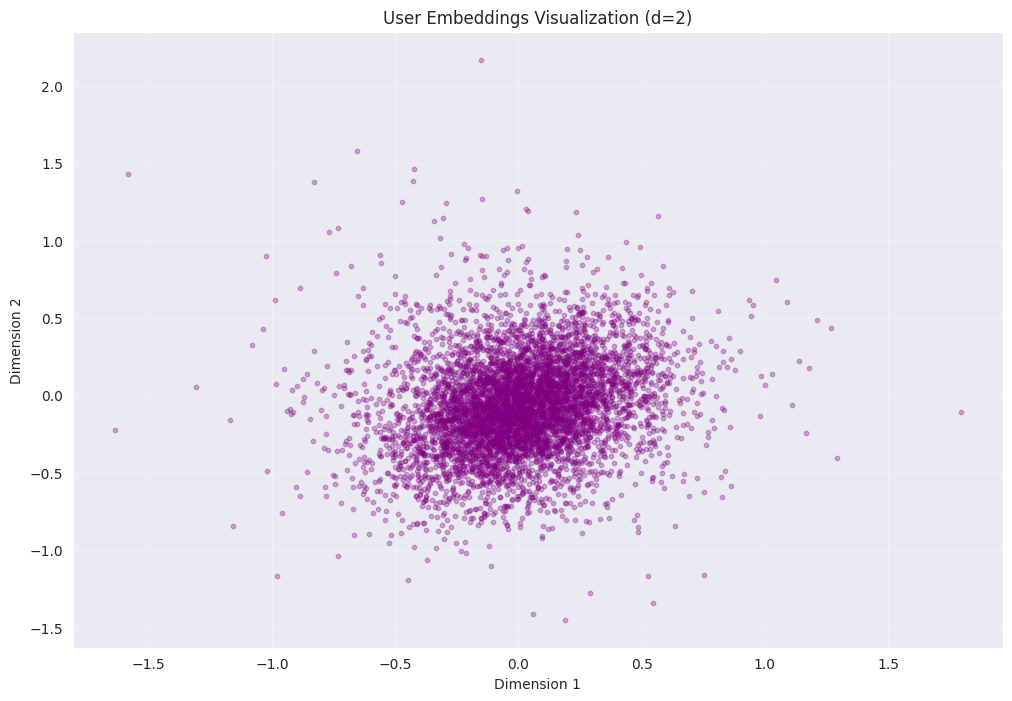

In [72]:
# Plot d=2 User Embeddings Visualization
user_embeddings_2d = mf_model_2d.A_
user_mapping_2d    = mf_model_2d.user_mapping_

user_2d_df = pd.DataFrame(
    user_embeddings_2d,
    index=user_mapping_2d,
    columns=['X', 'Y'])
print("User 2D Shape:", user_2d_df.shape)
# Plot
plt.figure(figsize=(12, 8))
plt.scatter(user_2d_df['X'],
            user_2d_df['Y'],
            alpha=0.3,
            color='purple',
            s=10)

plt.title('User Embeddings Visualization (d=2)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True, alpha=0.3)
plt.show()

##### 📊 Insight: User Embeddings (d=2)

Each dot represents one user.
Position (X,Y) = user's taste embedding
learned by Matrix Factorization.

**Key Observations:**

1. Dense Central Cluster:
   Majority of users cluster near center
   indicating most users have mainstream
   movie preferences — they enjoy popular
   widely-rated movies!

2. Edge Users = Niche Viewers:
   Users scattered at edges have unique
   taste preferences — they enjoy specific
   types of movies different from
   mainstream viewers.

3. Elliptical Shape:
   User embeddings form an elliptical
   distribution — wider horizontally
   indicating Dimension 1 captures more
   variation in user preferences than
   Dimension 2.

4. Compare with Movie Plot:
   Both plots show similar gaussian
   distribution — confirming MF learned
   balanced representations for both
   movies and users.

5. Users at far edges:
   These outlier users have very unique
   taste — could be critics or users
   with highly specialized preferences!

### 4.4 User-Based Collaborative Filtering
        (Optional)

### What is User-Based CF?
User-Based Collaborative Filtering finds
users similar to a new user based on their
rating patterns and recommends movies that
similar users enjoyed.

### Approach:
Step 1: Ask new user to rate few movies
        → Create new user dataframe

Step 2: Find users who watched
        same movies as new user
        → Common movie filter

Step 3: Sort users by count of
        most movies in common
        → More common = more relevant!

Step 4: Take top 100 users
        → Calculate Pearson Correlation
        → Get similarity scores

Step 5: Get top 10 similar users
        → Get all their movies
        → Add Weighted Ratings
          (Rating × Similarity Score)

Step 6: Calculate average
        recommendation score
        → Weighted Rating / Similarity

Step 7: Recommend top 10 movies
        → Movies not seen by new user
        → Highest recommendation score! ✅

### Why Pearson Correlation?
→ Measures rating PATTERN similarity
→ Handles rating bias
   (some users always rate high/low)
→ Range: -1 to +1
→ Best for user similarity! ✅

In [73]:
# Ask new user to rate movies
new_user_ratings = {
    'Toy Story (1995)'           : 5,
    'Titanic (1997)'             : 4,
    'Matrix, The (1999)'         : 5,
    'Liar Liar (1997)'           : 3,
    'Jurassic Park (1993)'       : 4,
    'Schindler\'s List (1993)'   : 5,
    'American Beauty (1999)'     : 4,
    'Silence of the Lambs, The (1991)': 4
}

# Create DataFrame
new_user_df = pd.DataFrame(
    new_user_ratings.items(),
    columns=['Title', 'Rating'])

print("New User Ratings:")
print(new_user_df)

New User Ratings:
                              Title  Rating
0                  Toy Story (1995)       5
1                    Titanic (1997)       4
2                Matrix, The (1999)       5
3                  Liar Liar (1997)       3
4              Jurassic Park (1993)       4
5           Schindler's List (1993)       5
6            American Beauty (1999)       4
7  Silence of the Lambs, The (1991)       4


In [74]:
# Get movies rated by new user
new_user_movies = new_user_df['Title'].tolist()

# Find users who watched same movies
# Filter df for only those movies
common_users = df[df['Title'].isin(
               new_user_movies)]
# Count how many common movies
# each user has with new user
user_common_count = common_users.groupby(
    'UserID')['Title'].count().reset_index()

user_common_count.columns = ['UserID',
                              'Common_Movies']

# Sort by most common movies
user_common_count = user_common_count.sort_values(
    'Common_Movies', ascending=False)

print("Users with common movies:")
print(f"Total users found: {len(user_common_count)}")
print(user_common_count.head(10))


Users with common movies:
Total users found: 5379
      UserID  Common_Movies
44        48              8
2629    2909              8
3677    4085              8
3125    3462              8
3133    3471              8
3137    3475              8
2259    2489              8
3290    3650              8
1459    1605              8
1435    1579              8


#### 📊 Insight: Common Users Analysis

**Results:**
- Total users found: **5,379 users**
- These users watched at least 1 movie
  in common with new user!

**Top users have 8 common movies** —
meaning they watched ALL 8 movies
rated by new user! ✅

**Why More Common Movies = Better?**
- More common movies → stronger evidence
  of similar taste! ✅
- Less common movies → might be
  just coincidence! ❌

**Strategy:**

→ Sort by most common movies ✅

→ Take top 100 users ✅

→ Calculate Pearson Similarity ✅

→ More reliable recommendations! ✅

In [75]:
# Take top 100 users
top_100_users = user_common_count.head(100)

# Get their ratings from main df
top_100_ratings = df[
    df['UserID'].isin(
    top_100_users['UserID'])]

print("Top 100 users ratings shape:",
      top_100_ratings.shape)
print(top_100_ratings.head())

Top 100 users ratings shape: (76907, 22)
      UserID  MovieID  Rating           Timestamp Gender  Age  Occupation  \
6511      48     2987       3 2000-12-29 03:09:57      M   25           4   
6512      48     2989       3 2000-12-29 05:02:44      M   25           4   
6513      48      719       2 2000-12-30 03:34:57      M   25           4   
6514      48      647       3 2000-12-28 14:23:33      M   25           4   
6515      48      648       3 2000-12-29 04:37:45      M   25           4   

     Zip-code                            Title                         Genres  \
6511    92107  Who Framed Roger Rabbit? (1988)  Adventure|Animation|Film-Noir   
6512    92107        For Your Eyes Only (1981)                         Action   
6513    92107              Multiplicity (1996)                         Comedy   
6514    92107        Courage Under Fire (1996)                      Drama|War   
6515    92107       Mission: Impossible (1996)       Action|Adventure|Mystery   

      ...

In [76]:
# Calculate Pearson Similarity:

from scipy.stats import pearsonr

# Get new user ratings as dictionary
new_user_dict = dict(zip(
    new_user_df['Title'],
    new_user_df['Rating']))

# Calculate Pearson Correlation
# for each of top 100 users
similarities = {}

for user_id in top_100_users['UserID']:

    # Get this user's ratings
    user_ratings = top_100_ratings[
        top_100_ratings['UserID'] == user_id][
        ['Title', 'Rating']]

    # Find common movies with new user
    common_movies = user_ratings[
        user_ratings['Title'].isin(
        new_user_dict.keys())]

    # Need at least 2 common movies
    if len(common_movies) >= 2:

        # Get ratings for common movies
        new_ratings  = [new_user_dict[m]
                       for m in
                       common_movies['Title']]
        user_ratings_list = common_movies[
                           'Rating'].tolist()

        # Calculate Pearson Correlation
        corr, _ = pearsonr(new_ratings,
                          user_ratings_list)
        similarities[user_id] = corr

# Convert to Series and sort
similarity_series = pd.Series(
    similarities).sort_values(ascending=False)

print("Similarity Scores (Top 10):")
print(similarity_series.head(10))

Similarity Scores (Top 10):
2041    0.866921
1340    0.830540
5880    0.826977
2895    0.809524
4007    0.801784
710     0.801784
1516    0.780399
2887    0.755929
48      0.714286
308     0.714286
dtype: float64


In [77]:
# Get top 10 similar users
top_10_users = similarity_series.head(10)
print("Top 10 Similar Users:")
print(top_10_users)

# Get all movies rated by top 10 users
top_10_ratings = df[
    df['UserID'].isin(
    top_10_users.index)]

# Add similarity score to ratings
top_10_ratings = top_10_ratings.copy()
top_10_ratings['Similarity'] = top_10_ratings['UserID'].map(top_10_users)

# Calculate Weighted Rating
# Weighted Rating = Rating × Similarity
top_10_ratings['Weighted_Rating'] = top_10_ratings['Rating'] * top_10_ratings['Similarity']

print("\nShape:", top_10_ratings.shape)
print(top_10_ratings[['UserID', 'Title',
      'Rating', 'Similarity',
      'Weighted_Rating']].head(10))

Top 10 Similar Users:
2041    0.866921
1340    0.830540
5880    0.826977
2895    0.809524
4007    0.801784
710     0.801784
1516    0.780399
2887    0.755929
48      0.714286
308     0.714286
dtype: float64

Shape: (6090, 24)
      UserID                                 Title  Rating  Similarity  \
6511      48       Who Framed Roger Rabbit? (1988)       3    0.714286   
6512      48             For Your Eyes Only (1981)       3    0.714286   
6513      48                   Multiplicity (1996)       2    0.714286   
6514      48             Courage Under Fire (1996)       3    0.714286   
6515      48            Mission: Impossible (1996)       3    0.714286   
6516      48            Little Rascals, The (1994)       3    0.714286   
6517      48                         Alien³ (1992)       3    0.714286   
6518      48            Herbie Goes Bananas (1980)       2    0.714286   
6519      48             Addams Family, The (1991)       3    0.714286   
6520      48  Bridge on the River 

In [78]:
# Group by movie title
recommendation_scores = top_10_ratings.groupby(
    'Title').agg(
    Weighted_Sum=('Weighted_Rating', 'sum'),
    Similarity_Sum=('Similarity', 'sum'),
    Avg_Rating=('Rating', 'mean')
).reset_index()

# Calculate final recommendation score
recommendation_scores['Rec_Score'] = recommendation_scores['Weighted_Sum'] / recommendation_scores['Similarity_Sum']

# Sort by recommendation score
recommendation_scores = recommendation_scores.sort_values('Rec_Score', ascending=False)

print("Recommendation Scores:")
print(recommendation_scores.head(10))

Recommendation Scores:
                                                  Title  Weighted_Sum  \
1697                              Third Man, The (1949)      3.571429   
1658                           Sweet and Lowdown (1999)      3.571429   
1209                               Nobody's Fool (1994)      3.571429   
1161        My Life as a Dog (Mitt liv som hund) (1985)      4.047619   
288                            Can't Hardly Wait (1998)      3.901995   
488                         Doom Generation, The (1995)      3.901995   
1440                                  Roger & Me (1989)     11.627966   
1496  Seven Samurai (The Magnificent Seven) (Shichin...      8.182503   
185                               Beyond the Mat (2000)      4.047619   
1402                         Requiem for a Dream (2000)      4.047619   

      Similarity_Sum  Avg_Rating  Rec_Score  
1697        0.714286         5.0        5.0  
1658        0.714286         5.0        5.0  
1209        0.714286         5.0   

In [79]:
# Remove movies new user already watched
new_user_watched = new_user_df['Title'].tolist()

# Filter out watched movies
final_recommendations = recommendation_scores[
    ~recommendation_scores['Title'].isin(
    new_user_watched)]

# Get top 10 recommendations
top_10_recommendations = final_recommendations.head(10)

print("=" * 50)
print("Top 10 Movie Recommendations")
print("for New User:")
print("=" * 50)

for i, (_, row) in enumerate(
    top_10_recommendations.iterrows(), 1):
    print(f"{i}. {row['Title']}")
    print(f"   Score     : {row['Rec_Score']:.4f}")
    print(f"   Avg Rating: {row['Avg_Rating']:.2f}")
    print()

Top 10 Movie Recommendations
for New User:
1. Third Man, The (1949)
   Score     : 5.0000
   Avg Rating: 5.00

2. Sweet and Lowdown (1999)
   Score     : 5.0000
   Avg Rating: 5.00

3. Nobody's Fool (1994)
   Score     : 5.0000
   Avg Rating: 5.00

4. My Life as a Dog (Mitt liv som hund) (1985)
   Score     : 5.0000
   Avg Rating: 5.00

5. Can't Hardly Wait (1998)
   Score     : 5.0000
   Avg Rating: 5.00

6. Doom Generation, The (1995)
   Score     : 5.0000
   Avg Rating: 5.00

7. Roger & Me (1989)
   Score     : 5.0000
   Avg Rating: 5.00

8. Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954)
   Score     : 5.0000
   Avg Rating: 5.00

9. Beyond the Mat (2000)
   Score     : 5.0000
   Avg Rating: 5.00

10. Requiem for a Dream (2000)
   Score     : 5.0000
   Avg Rating: 5.00



#### 📊 Insight: User-Based Recommendations

Top 10 movies recommended for new user
based on ratings by 10 most similar users.

All recommendations score 5.0 — these
movies were rated 5⭐ by users with
similar taste patterns to new user.

Mix of genres and decades:

→ Classic (Third Man 1949, Seven Samurai)

→ Modern (Requiem for a Dream 2000)

→ Documentary (Roger & Me, Beyond the Mat)

This shows User-Based CF recommends
movies based on TASTE SIMILARITY
not just genre or popularity!

### 4.5 Evaluation — Precision@K & Recall@K

### Why Ranking Metrics?
RMSE measures prediction accuracy but
recommender systems need ranking metrics!

- **Precision@K**: Of K recommendations,
  how many were relevant? ✅
- **Recall@K**: Of all relevant movies,
  how many did we recommend? ✅

A movie is considered **relevant** if
user rated it **4 or above** ⭐⭐⭐⭐

In [80]:
def precision_recall_at_k(model, train_data, test_data, all_movies, k=5, threshold=4.0):

    test_users = test_data['UserID'].unique()
    precisions = []
    recalls = []

    for user_id in test_users[:500]:  # Using 500 users for speed

        # Movies rated highly by this user in test set
        relevant = test_data[
            (test_data['UserID'] == user_id) &
            (test_data['Rating'] >= threshold)
        ]['MovieID'].tolist()

        if len(relevant) == 0:
            continue

        # Movies already seen in training
        train_movies = train_data[
            train_data['UserID'] == user_id
        ]['MovieID'].tolist()

        # Candidate movies = all movies not seen in train
        candidates = [m for m in all_movies if m not in train_movies]

        if len(candidates) == 0:
            continue

        # Predict ratings
        predictions = model.predict(
            user=[user_id] * len(candidates),
            item=candidates
        )

        # Top-K recommendations
        top_k = pd.Series(predictions, index=candidates).sort_values(
            ascending=False
        ).head(k).index.tolist()

        hits = len([m for m in top_k if m in relevant])

        precision = hits / len(top_k) if len(top_k) > 0 else 0
        recall = hits / len(relevant) if len(relevant) > 0 else 0

        precisions.append(precision)
        recalls.append(recall)

    avg_precision = np.mean(precisions) if precisions else 0
    avg_recall = np.mean(recalls) if recalls else 0

    return avg_precision, avg_recall

In [81]:
all_movies = df['MovieID'].unique()

for k in [5, 10]:
    precision, recall = precision_recall_at_k(
        mf_model, train_data, test_data, all_movies, k=k
    )
    print(f"K={k}:")
    print(f"  Precision@{k}: {precision:.4f}")
    print(f"  Recall@{k}: {recall:.4f}")
    print()

K=5:
  Precision@5: 0.2264
  Recall@5: 0.0319

K=10:
  Precision@10: 0.1916
  Recall@10: 0.0544



#### 📊 Insight: Precision@K & Recall@K

**Evaluation Results:**

| Metric | K=5 | K=10 |
|--------|-----|------|
| Precision@K | 0.2264 | 0.1916 |
| Recall@K | 0.0319 | 0.0544 |

---

### 🧠 What This Means

- **Precision@5 = 0.2264** → ~22.64% of the top 5 recommendations are relevant  
- **Recall@5 = 0.0319** → The model captures ~3.19% of relevant movies in the test set  

---

### ⚖️ Precision–Recall Trade-off

- As **K increases**, Precision decreases slightly ⚠️  
- As **K increases**, Recall increases ✅  
- This trade-off is expected in recommender systems, as recommending more items increases coverage but may reduce relevance  

---

### 📉 Why Recall Is Low

- Large candidate space (~3,706 movies)  
- Highly sparse user–item matrix (~95.5% sparsity)  
- Only a small **top-K subset** is recommended  

---

### 📌 Interpretation

- **Precision@10 = 0.1916** indicates the model is able to **rank relevant items reasonably well within top recommendations**  
- The model prioritizes **precision over recall**, focusing on showing fewer but more relevant items  

---

### 🔍 RMSE vs Ranking Metrics

- **RMSE** evaluates how accurately ratings are predicted  
- **Precision@K / Recall@K** evaluate the quality of top-N recommendations  

➡️ In real-world systems, **ranking metrics are often more important**, since users interact mainly with top recommendations  

---

### 📊 Complete Model Evaluation

| Metric | Value |
|-------|--------|
| Baseline RMSE | 0.9824 |
| MF RMSE (d=4) | 0.8644 |
| Improvement | 11.6% |
| Precision@5 | 0.2264 |
| Recall@5 | 0.0319 |
| Precision@10 | 0.1916 |
| Recall@10 | 0.0544 |
| MAPE        | 26.4007% |

## 5. Questionnaire Answers

### Q1: Users of which age group have watched and rated the most movies?

Answer: 25-34 age group with ~395,000
ratings — almost double the second
highest group (35-44). Young working
adults are the most active users!

───────────────────────────────────────────────────────────

### Q2: Users belonging to which profession have watched and rated the most movies?

Answer: College/Grad Students with
~128,000 ratings, closely followed by
'other' category. This aligns with the
25-34 age group finding!

───────────────────────────────────────────────────────────

### Q3: Most users who rated movies are Male. (T/F)

Answer: TRUE

Male   → 753,769 ratings (75.3%)

Female → 246,440 ratings (24.7%)

3:1 ratio of male to female users!

───────────────────────────────────────────────────────────

### Q4: Most movies were released in which decade?

Answer: (b) 1990s

1990s → 2152 unique movies
Almost 4x more than 1980s (592)!

Dataset collected around 2000 so
recent movies naturally dominate!

───────────────────────────────────────────────────────────

### Q5: The movie with maximum number of ratings is?

Answer: American Beauty (1999)
with 3428 ratings!

Followed by Star Wars Episode IV (2991)
and Star Wars Episode V (2990)

───────────────────────────────────────────────────────────

### Q6: Top 3 movies similar to 'Liar Liar' (Item-Based)?

Using Pearson Correlation:
1. Face in the Crowd, A (1957)
2. Groove (2000)
3. Whatever (1998)

Using KNN Cosine Similarity:
1. Mrs. Doubtfire (1993)
2. Ace Ventura: Pet Detective (1994)
3. Dumb & Dumber (1994)

───────────────────────────────────────────────────────────

### Q7: Collaborative Filtering can be classified into ___-based and ___-based?

Answer: ITEM-based and USER-based

Item-Based:

→ Finds similarity between MOVIES

→ "Users who liked Movie A
   also liked Movie B"

User-Based:

→ Finds similarity between USERS

→ "Users similar to you
   also liked Movie X"

───────────────────────────────────────────────────────────

### Q8: Pearson Correlation ranges between ___ to ___ whereas Cosine Similarity belongs to ___ to ___?

Answer:
Pearson Correlation → -1 to +1

→ +1 = Perfect positive correlation

→  0 = No correlation

→ -1 = Perfect negative correlation

Cosine Similarity → 0 to 1

→ 1 = Identical vectors

→ 0 = Completely different vectors

Key Difference:

Pearson can be negative (opposite taste!)

Cosine is always positive (0 to 1)

───────────────────────────────────────────────────────────

### Q9: RMSE and MAPE from Matrix Factorization?

Answer:

RMSE : 0.8644

MAPE : 26.4007%

RMSE of 0.8644 means predictions are
on average less than 1 star away from
actual ratings — good performance!

MAPE of 26.4% is expected for sparse
rating data as low ratings (1-2) cause
high percentage errors.

───────────────────────────────────────────────────────────

### Q10: Sparse row matrix representation for dense matrix [[1,0],[3,7]]?

Answer:

Dense Matrix:

[[1, 0],

 [3, 7]]

CSR (Compressed Sparse Row)

representation:

(0, 0)  →  1   (row 0, col 0, value 1)

(1, 0)  →  3   (row 1, col 0, value 3)

(1, 1)  →  7   (row 1, col 1, value 7)


0 at position (0,1) is ignored! ✅

Only 3 non-zero values stored
instead of 4! ✅

Memory saved = 25%!

In [82]:
# Verify Q10
import numpy as np
from scipy.sparse import csr_matrix

dense = np.array([[1, 0],
                  [3, 7]])
sparse = csr_matrix(dense)
print("Dense Matrix:")
print(dense)
print("\nCSR Representation:")
print(sparse)

Dense Matrix:
[[1 0]
 [3 7]]

CSR Representation:
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3 stored elements and shape (2, 2)>
  Coords	Values
  (0, 0)	1
  (1, 0)	3
  (1, 1)	7


## 📌 Conclusion

In this project, we built a movie recommendation system using the MovieLens 1M dataset and explored multiple recommendation approaches, including:

- Popularity-based baseline  
- User-based and Item-based Collaborative Filtering  
- Cosine Similarity with KNN  
- Matrix Factorization  

---

### 📊 Key Outcomes

- Matrix Factorization achieved the best performance with an RMSE of **0.8644**, improving **11.6% over the baseline**  
- The model demonstrated reasonable ranking performance with:
  - Precision@5 ≈ **22.64%**
  - Precision@10 ≈ **19.16%**

---

### 🧠 Key Learnings

- Establishing a **baseline model** is essential to measure real improvements  
- RMSE alone is not sufficient for recommender systems; **ranking metrics like Precision@K and Recall@K** better reflect recommendation quality  
- Recommender systems involve trade-offs between **accuracy, personalization, and scalability**  

---

### ⚠️ Limitations

- High sparsity (~95.5%) limits model performance  
- **Cold start problem**:
  - New users require initial interactions (ratings) to generate recommendations  
  - New items cannot be recommended without prior interactions  
- Evaluation is based on offline metrics and may differ from real-world user behavior  

---

### 🚀 Future Improvements

- Incorporate advanced ranking metrics like **NDCG@K**  
- Build a **hybrid recommender system** combining collaborative and content-based filtering  
- Handle cold start for new items using **content-based features**  
- Incorporate **implicit feedback** (clicks, watch time, etc.)  
- Deploy the model using a web application (e.g., Streamlit or FastAPI)  

---

### 🎯 Final Takeaway

This project demonstrates how collaborative filtering and matrix factorization can be used to build personalized recommendation systems, along with the importance of proper evaluation, baseline comparison, and understanding real-world limitations such as sparsity and cold start.

### 💼 Business Recommendations

1. Target users in the **25–34 age group** with personalized recommendations, as they form the largest active segment  

2. Use **Matrix Factorization** for accurate rating prediction and personalized recommendations  

3. Use **KNN-based similarity models** for intuitive "similar movies" suggestions  

4. Mitigate cold start for new users by asking them to rate **5–10 movies initially**  

5. Focus on popular genres like **Comedy and Drama** to improve engagement and recommendation relevance  